# ML Credit Risk Pipeline
### Loan Approval Prediction — Binary Classification

An end-to-end machine learning pipeline that predicts whether a bank loan
application will be **approved** or **rejected**, based on applicant
financial, asset, and demographic data.

## 1. Project Overview & Problem Formulation

**Objective.** Build and compare multiple classification models that predict
`loan_status` (Approved / Rejected) from applicant attributes such as income,
credit score (CIBIL), assets, and loan terms, and identify the model that
generalizes best to unseen applicants.

**Why it matters.** Automated credit-risk screening lets a financial
institution triage loan applications faster and more consistently than
manual review, while surfacing the key drivers behind each decision.

**Pipeline at a glance:**

| Stage | What happens |
|---|---|
| EDA | Distribution, skewness, correlation, and outlier analysis |
| Preprocessing | Encoding, outlier removal, feature selection (Pearson + Mutual Information) |
| Imbalance handling | SMOTE oversampling on the training split only |
| Scaling | Z-score standardization |
| Modeling | Logistic Regression, Decision Tree, Random Forest, KNN, SVM, XGBoost — each tuned via `GridSearchCV` |
| Evaluation | Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, t-SNE projections |
| Robustness check | Impact of removing the dominant feature (`cibil_score`) |



In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

In [67]:
df = pd.read_csv("loan_approval.csv")

In [68]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000.0,12,778,2400000.0,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000.0,8,417,2700000.0,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000.0,20,506,7100000.0,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000.0,8,467,18200000.0,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000.0,20,382,12400000.0,8200000,29400000,5000000,Rejected


In [69]:
df.shape

(4279, 13)

### Initial Data Inspection

`df.info()` surfaces column dtypes and null counts; `df.describe()` gives the
distribution (mean, std, quartiles) of every numerical column; and
`value_counts()` on the target exposes class balance up front.

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4279 entries, 0 to 4278
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4279 non-null   int64  
 1   no_of_dependents          4279 non-null   int64  
 2   education                 4279 non-null   object 
 3   self_employed             4150 non-null   object 
 4   income_annum              4279 non-null   int64  
 5   loan_amount               3928 non-null   float64
 6   loan_term                 4279 non-null   int64  
 7   cibil_score               4279 non-null   int64  
 8   residential_assets_value  4021 non-null   float64
 9   commercial_assets_value   4279 non-null   int64  
 10  luxury_assets_value       4279 non-null   int64  
 11  bank_asset_value          4279 non-null   int64  
 12  loan_status               4279 non-null   object 
dtypes: float64(2), int64(8), object(3)
memory usage: 434.7+ KB


In [71]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4279.000000,4279.000000,4.279000e+03,3.928000e+03,4279.000000,4279.000000,4.021000e+03,4.279000e+03,4.279000e+03,4.279000e+03
mean,2134.562515,2.500351,5.059547e+06,1.519646e+07,10.903950,599.896705,7.441507e+06,4.977401e+06,1.512744e+07,4.979692e+06
std,1232.098421,1.695341,2.804954e+06,9.056741e+06,5.705724,172.297707,6.496085e+06,4.391024e+06,9.098122e+06,3.248077e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,0.000000e+00,0.000000e+00,3.000000e+05,0.000000e+00
25%,1069.500000,1.000000,2.700000e+06,7.775000e+06,6.000000,453.500000,2.100000e+06,1.300000e+06,7.500000e+06,2.400000e+06
50%,2133.000000,3.000000,5.100000e+06,1.460000e+07,10.000000,600.000000,5.500000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.500000,4.000000,7.500000e+06,2.160000e+07,16.000000,747.000000,1.130000e+07,7.650000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [72]:
df['loan_status'].value_counts()

loan_status
Approved    2662
Rejected    1617
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA) & Insights

### 2.1 Data Cleaning

In [73]:
# Remove duplicate records, if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

In [74]:
# Drop the identifier column — it carries no predictive signal
df = df.drop("loan_id", axis=1)

In [75]:
# Check for missing values
df.isna().sum()

no_of_dependents              0
education                     0
self_employed               128
income_annum                  0
loan_amount                 341
loan_term                     0
cibil_score                   0
residential_assets_value    256
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value              0
loan_status                   0
dtype: int64

**Missing-value strategy.**

| Column | Type | Method | Rationale |
|---|---|---|---|
| `self_employed` | Categorical | Mode | Most frequent category best represents a nominal feature. |
| `residential_assets_value` | Numerical, skewed | Median | Robust to outliers, unlike the mean. |
| `loan_amount` | Numerical, ~symmetric | Mean | No significant outliers, so the mean uses all data equally. |


In [76]:
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].mean())
df['residential_assets_value'] = df['residential_assets_value'].fillna(df['residential_assets_value'].median())

### 2.2 Distribution & Skewness

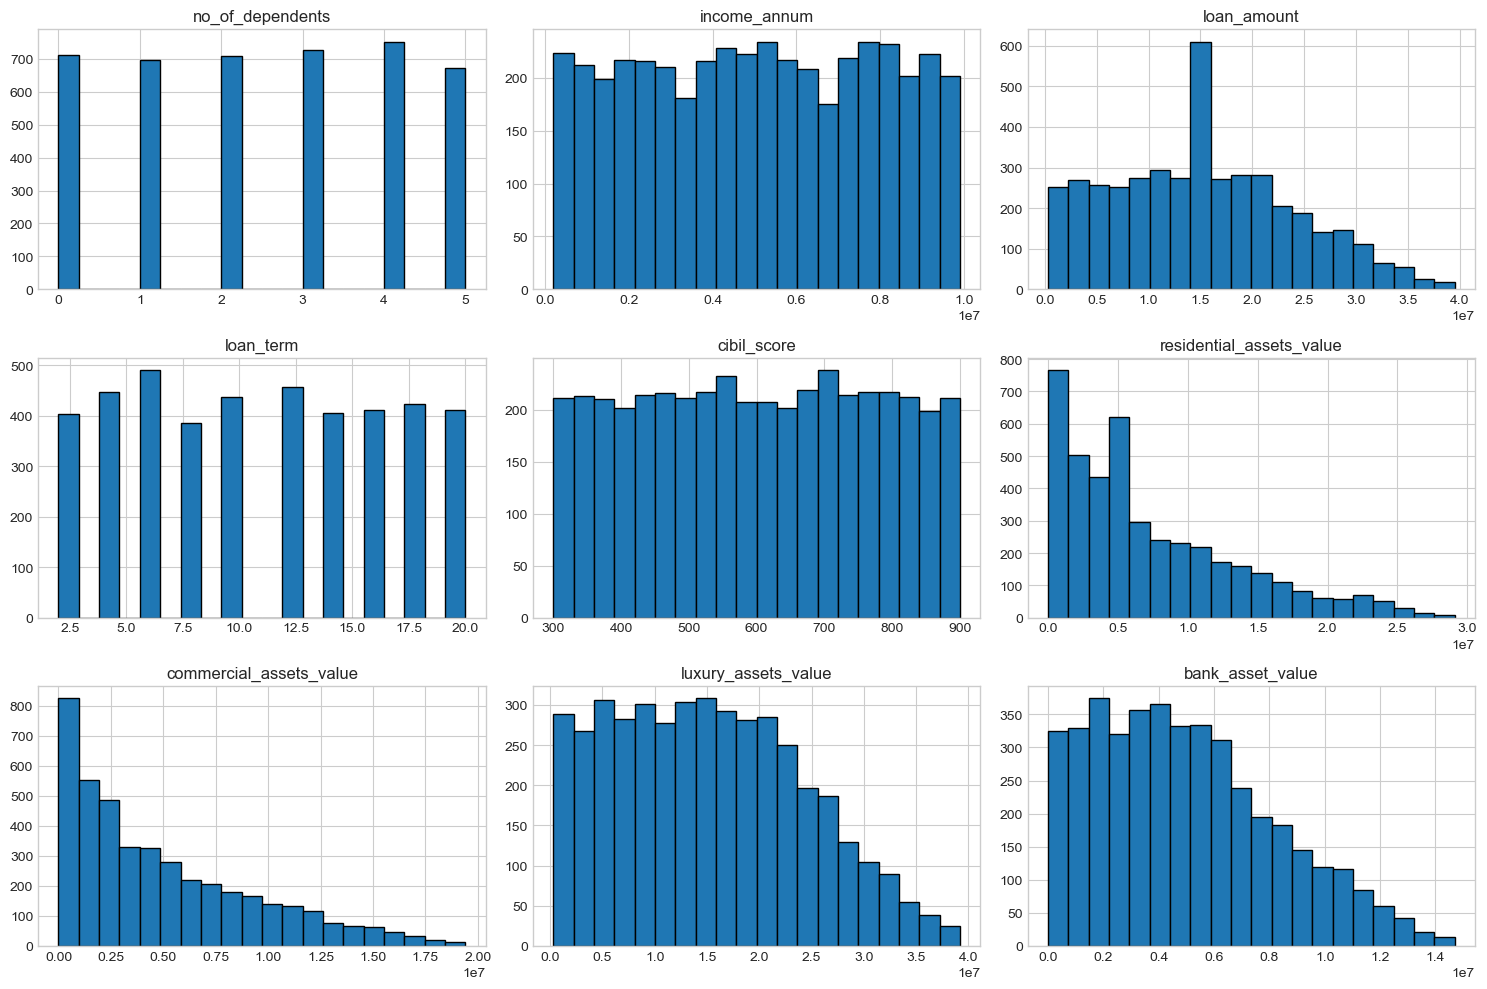

In [77]:
# Distribution of numerical features
df.select_dtypes(include='number').columns

df.hist(figsize=(15, 10), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

**Skewness reading.** `residential_assets_value` and
`commercial_assets_value` show strong positive (right) skew — most
applicants cluster at low values with a long tail of high-asset outliers.
`bank_asset_value` and `loan_amount` are mildly positively skewed, and
`luxury_assets_value` only slightly so. `income_annum`, `cibil_score`,
`loan_term`, and `no_of_dependents` are approximately symmetric. No feature
shows negative skew — consistent with typical financial data, and the
reason median (not mean) was used to impute the skewed asset column above.

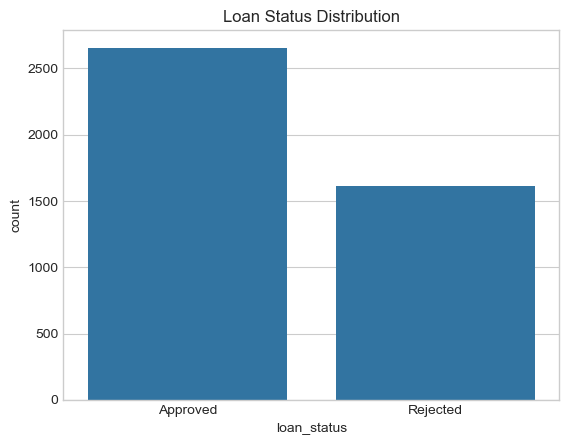

In [78]:
sns.countplot(data=df, x='loan_status')
plt.title('Loan Status Distribution')
plt.show()

### 2.3 Correlation Analysis

The Pearson correlation coefficient measures the strength and direction of a
**linear** relationship between two numeric variables:

$$
r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

$r \in [-1, 1]$: values near $\pm1$ indicate strong linear association, and
values near 0 indicate little to none. The numerator is the covariance
between the two variables; the denominator normalizes by their individual
spreads, which is what bounds $r$ to $[-1, 1]$.

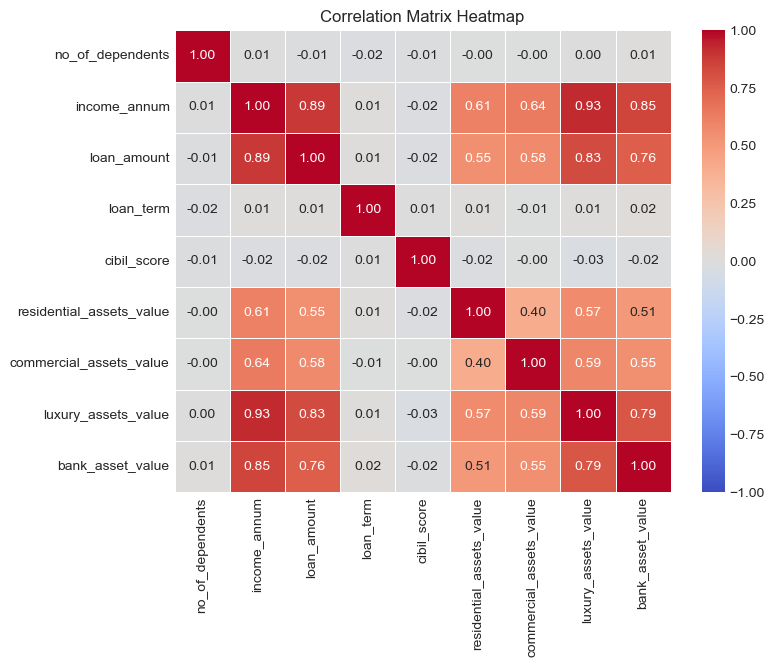

In [79]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix Heatmap')
plt.show()

**Heatmap insight.** The strongest positive correlations are
`income_annum` ↔ `luxury_assets_value` (**r ≈ 0.93**) and `income_annum` ↔
`loan_amount` (**r ≈ 0.89**) — higher income tracks with larger assets and
larger loan requests, as expected. No meaningful negative correlation
exists in the data; the largest (`cibil_score` ↔ `luxury_assets_value`,
**r ≈ −0.03**) is negligible. Relationships in this dataset are
predominantly positive.

### 2.4 Outlier Detection (Box Plots)

A box plot compactly summarizes a distribution via its quartiles and flags
outliers using the **Interquartile Range (IQR)** rule:

$$IQR = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times IQR \qquad \text{Upper Bound} = Q_3 + 1.5 \times IQR$$

Any point outside $[\text{Lower Bound}, \text{Upper Bound}]$ is flagged as an
outlier. Components: **Q1** (25th percentile), **median/Q2**, **Q3** (75th
percentile), the **box** (middle 50% of the data, Q1–Q3), the **whiskers**
(normal-range extent), and individually plotted **outlier** points.

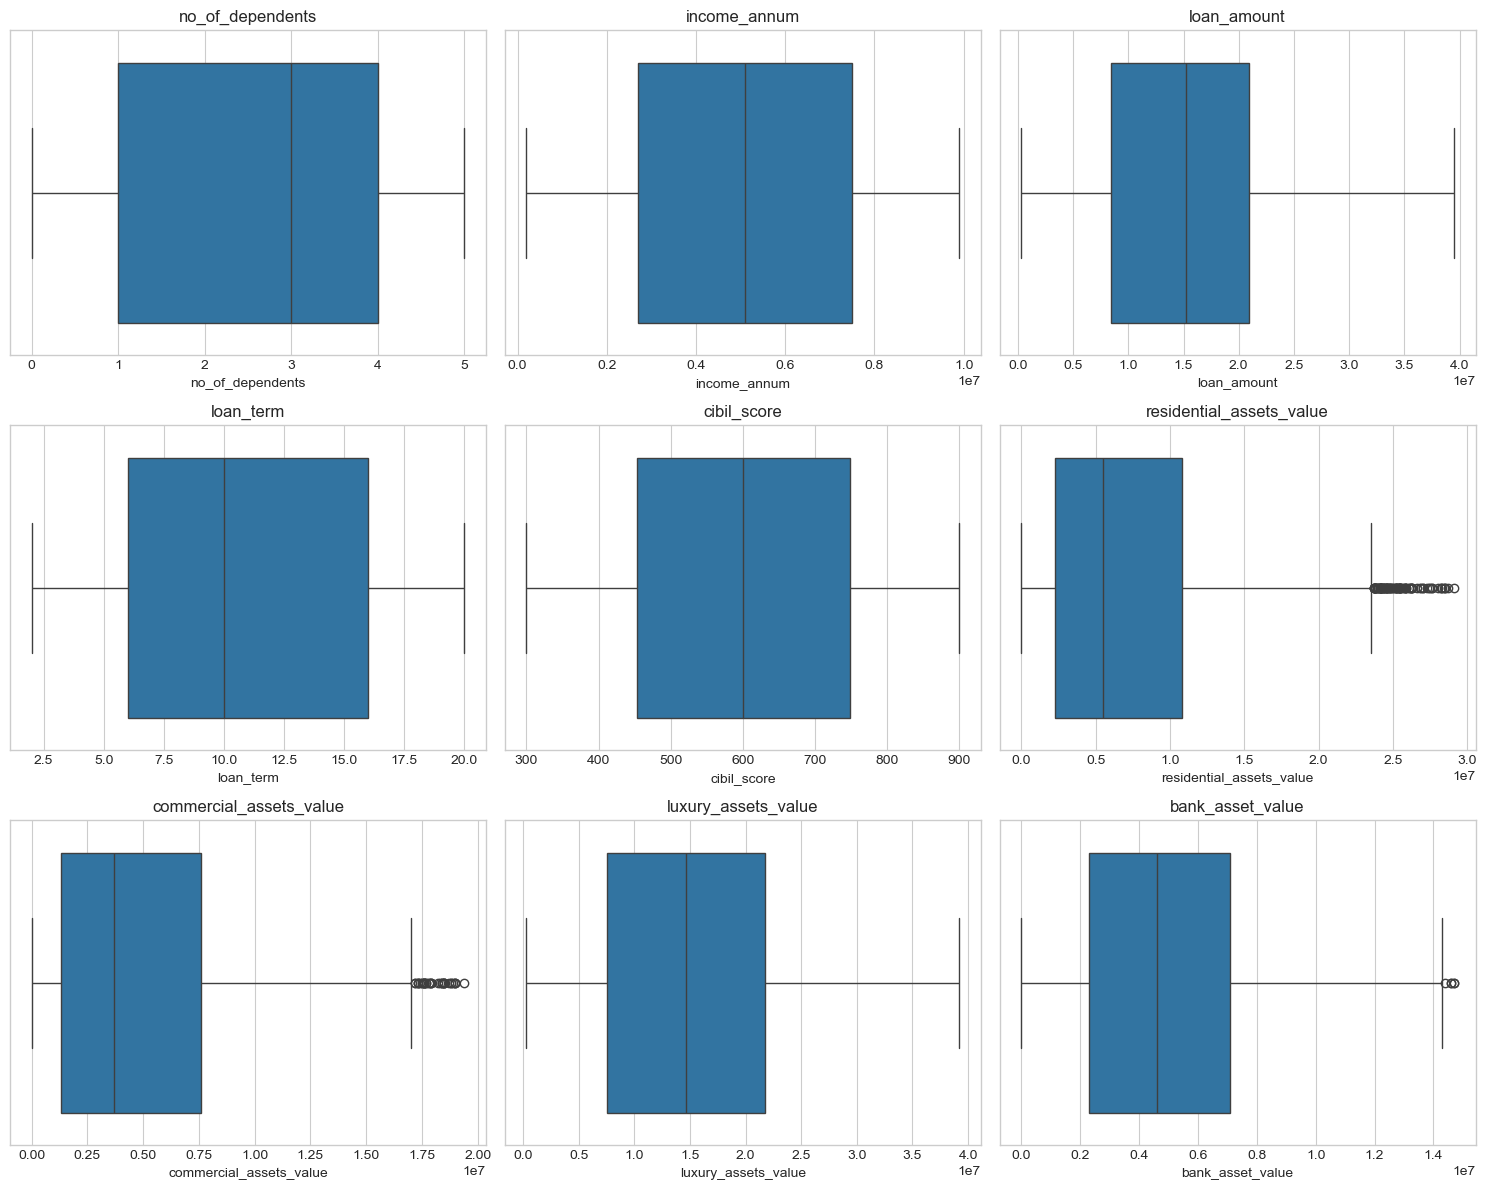

In [80]:
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Outlier reading.** `residential_assets_value`, `commercial_assets_value`,
and `bank_asset_value` each show a modest number of high-end outliers — a
small subset of applicants with disproportionately large asset holdings.
`income_annum`, `loan_amount`, `luxury_assets_value`, `cibil_score`,
`loan_term`, and `no_of_dependents` show no notable outliers. No feature
shows low-end outliers — all flagged points sit above the upper whisker,
consistent with the positive skew observed earlier. Note that box plots are
a poor fit for low-cardinality features like `loan_term` and
`no_of_dependents`, though still usable for a rough read of spread.

## 3. Data Preprocessing & Feature Engineering

### 3.1 Categorical Encoding

ML models require numeric input, so categorical features must be encoded.
Categorical features are either **nominal** (no inherent order) or
**ordinal** (a meaningful order exists). Two common encodings:

- **One-Hot Encoding** — creates one binary column per category. Best for
  nominal features with no ordering.
- **Ordinal Encoding** — maps each category to an integer; only appropriate
  when the assigned order and spacing are meaningful.

In [81]:
df.dtypes

no_of_dependents              int64
education                    object
self_employed                object
income_annum                  int64
loan_amount                 float64
loan_term                     int64
cibil_score                   int64
residential_assets_value    float64
commercial_assets_value       int64
luxury_assets_value           int64
bank_asset_value              int64
loan_status                  object
dtype: object

In [82]:
print(df['education'].unique())
print(df['self_employed'].unique())
print(df['loan_status'].unique())

['Graduate' 'Not Graduate']
['No' 'Yes']
['Approved' 'Rejected']


In [83]:
# Target: binary-encode Approved/Rejected
df['loan_status'] = df['loan_status'].map({
    'Rejected': 0,
    'Approved': 1
})

# Nominal categorical features: one-hot encode
df = pd.get_dummies(
    df,
    columns=['education', 'self_employed'],
    drop_first=True
)

print(df.dtypes)

no_of_dependents              int64
income_annum                  int64
loan_amount                 float64
loan_term                     int64
cibil_score                   int64
residential_assets_value    float64
commercial_assets_value       int64
luxury_assets_value           int64
bank_asset_value              int64
loan_status                   int64
education_Not Graduate         bool
self_employed_Yes              bool
dtype: object


**Encoding rationale.** `education` and `self_employed` are nominal with
no natural ordering, so **One-Hot Encoding** applies. `loan_status` is the
binary target, encoded directly as `Approved → 1`, `Rejected → 0`.

### 3.2 Outlier Removal

Applying the IQR method iteratively removes residual outliers in
`bank_asset_value` — the feature with the clearest, most consistent outlier
pattern from the box plots above.

In [84]:
def remove_outliers_iqr(df, col):
    while True:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        if len(outliers) == 0:
            break

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

outlier_column = 'bank_asset_value'
df = remove_outliers_iqr(df, outlier_column)

print(f"Shape after removing outliers: {df.shape}")

Shape after removing outliers: (4264, 12)


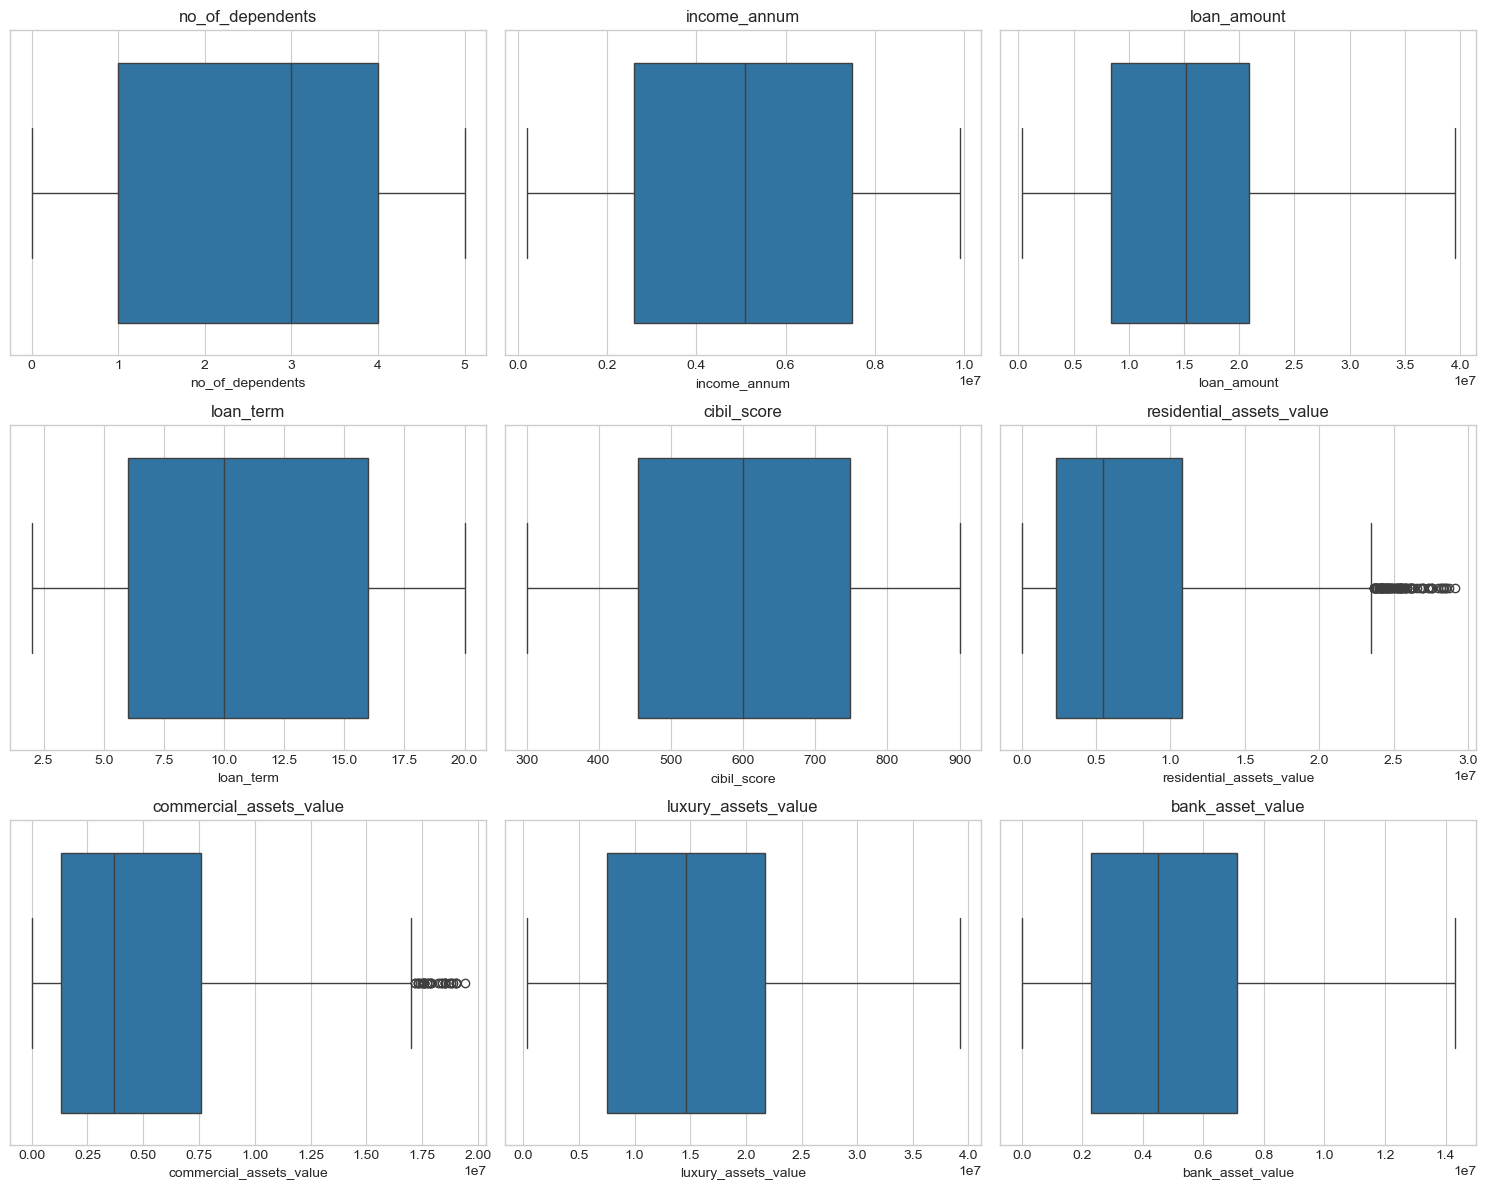

In [85]:
# Re-check numerical features post-encoding (binary encoded columns excluded — box plots aren't meaningful for 0/1 values)
numeric_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### 3.3 Feature Selection — Pearson + Mutual Information

Pearson correlation only captures **linear** relationships. **Mutual
Information (MI)** complements it by also capturing non-linear dependence:

$$
I(X;Y) = \sum_{x \in X}\sum_{y \in Y} p(x,y)\log\left(\frac{p(x,y)}{p(x)p(y)}\right)
$$

MI is always $\geq 0$; it is 0 for independent variables and increases with
dependency strength, linear or not.

In [86]:
target_corr = df.corr()['loan_status'].drop('loan_status')
sorted_corr = target_corr.abs().sort_values(ascending=False)

print("Pearson correlation with loan_status (sorted by absolute value):\n")
print(sorted_corr)

print("\nPearson correlation with loan_status (with original sign):\n")
for col in sorted_corr.index:
    print(f"{col:30s}: {target_corr[col]:+.6f}")

Pearson correlation with loan_status (sorted by absolute value):

cibil_score                 0.770462
loan_term                   0.113023
no_of_dependents            0.017700
residential_assets_value    0.015065
loan_amount                 0.014455
luxury_assets_value         0.014430
income_annum                0.014312
commercial_assets_value     0.009789
bank_asset_value            0.005233
education_Not Graduate      0.004019
self_employed_Yes           0.001622
Name: loan_status, dtype: float64

Pearson correlation with loan_status (with original sign):

cibil_score                   : +0.770462
loan_term                     : -0.113023
no_of_dependents              : -0.017700
residential_assets_value      : -0.015065
loan_amount                   : +0.014455
luxury_assets_value           : -0.014430
income_annum                  : -0.014312
commercial_assets_value       : +0.009789
bank_asset_value              : -0.005233
education_Not Graduate        : -0.004019
self_employe

In [87]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# mutual_info_classif assumes continuous features by default; flag low-cardinality columns as discrete
discrete_features = X.nunique() < 20

mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=42)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print(mi_scores)

cibil_score                 0.504907
loan_term                   0.019454
bank_asset_value            0.005802
luxury_assets_value         0.003376
commercial_assets_value     0.000563
no_of_dependents            0.000271
education_Not Graduate      0.000008
self_employed_Yes           0.000001
income_annum                0.000000
loan_amount                 0.000000
residential_assets_value    0.000000
dtype: float64


**Pearson vs. MI.** Both metrics agree that `cibil_score` is by far the
strongest predictor of `loan_status` (Pearson **r ≈ 0.77**, MI **≈ 0.505**),
followed at a distance by `loan_term`, `bank_asset_value`, and
`loan_amount`. The two rankings aren't identical — `loan_term` scores
noticeably higher under MI than under Pearson — because Pearson only
detects linear relationships while MI also picks up non-linear ones. The
two methods are consistent with the correlation heatmap overall, and the
discrepancies are explained by MI's sensitivity to non-linear dependence.

**Selection rule:** keep any feature that clears *either* threshold —
the median Pearson |r|, or an MI score above `0.0005` — taking the union of
both selected sets.

In [88]:
pearson_threshold = sorted_corr.median()
pearson_selected = sorted_corr[sorted_corr >= pearson_threshold].index.tolist()

mi_threshold = 0.00005
mi_selected = mi_scores[mi_scores > mi_threshold].index.tolist()

final_selected = sorted(list(set(pearson_selected) | set(mi_selected)))

print(f"Pearson selected: {pearson_selected}")
print(f"MI selected: {mi_selected}")
print(f"Final selected features: {final_selected}")
print(f"Total number of columns (with loan_status): {len(final_selected) + 1}")

df = df[final_selected + ['loan_status']]
print(df.shape)

Pearson selected: ['cibil_score', 'loan_term', 'no_of_dependents', 'residential_assets_value', 'loan_amount', 'luxury_assets_value']
MI selected: ['cibil_score', 'loan_term', 'bank_asset_value', 'luxury_assets_value', 'commercial_assets_value', 'no_of_dependents']
Final selected features: ['bank_asset_value', 'cibil_score', 'commercial_assets_value', 'loan_amount', 'loan_term', 'luxury_assets_value', 'no_of_dependents', 'residential_assets_value']
Total number of columns (with loan_status): 9
(4264, 9)


### 3.4 Train/Test Split

The dataset is split before any further preprocessing to prevent
**data leakage** — information from the test set inadvertently influencing
training (e.g., fitting a scaler or imputer on the full dataset, or
selecting features using test-set statistics). All downstream preprocessing
(resampling, scaling) is fit on the training split only.

In [89]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3411, 8)
X_test shape: (853, 8)
y_train shape: (3411,)
y_test shape: (853,)


### 3.5 Class Imbalance Handling

Class imbalance is corrected **only on the training split** — the test set
must remain untouched to give an unbiased read of real-world performance.

In [90]:
print(y_train.value_counts())

loan_status
1    2134
0    1277
Name: count, dtype: int64


**SMOTE** was chosen over Random Over/Undersampling: it generates
synthetic minority-class samples instead of duplicating existing ones
(lower overfitting risk than naive oversampling) or discarding majority-class
data (unlike undersampling, which loses information). Applying resampling
to the training data only is essential — leaking it into the test set would
artificially inflate reported performance.

In [91]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
loan_status
1    2134
0    1277
Name: count, dtype: int64

After SMOTE:
loan_status
1    2134
0    2134
Name: count, dtype: int64


### 3.6 Feature Scaling

**Z-score standardization** was used over Min-Max normalization because
several features are skewed with outliers (Section 2.4), and standardization
is less sensitive to extreme values than a fixed-range rescaling. As with
resampling, the scaler is **fit on training data only** and then applied to
the test set, matching how new data would be scaled in production.

$$X_{\text{standardized}} = \frac{X - \mu}{\sigma}$$

The target column is intentionally left unscaled — it's a categorical label
(0/1), not a continuous feature the model is fit against, and rescaling it
would destroy its meaning as a class indicator.

In [92]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (4268, 8)
X_test_scaled shape: (853, 8)


## 4. Model Training, Baseline & Hyperparameter Optimization

### 4.1 Cross-Validation & Hyperparameter Tuning

**K-Fold Cross-Validation** evaluates a model across $K$ train/test splits
rather than a single split, giving a more reliable performance estimate. A
smaller $K$ (e.g. 3) is faster but noisier; a larger $K$ (e.g. 10) gives
more stable estimates at higher computational cost — 5 or 10 is the common
sweet spot. **Stratified K-Fold** additionally preserves the class ratio in
every fold, which matters here given the class imbalance.

**Hyperparameter search strategies:**

| Method | How it works | Trade-off |
|---|---|---|
| **Grid Search** | Exhaustively tries every combination in a defined grid | Guaranteed to find the best grid point, but scales poorly with grid size |
| **Random Search** | Samples a fixed number of random combinations | Faster, scales better, no guarantee of finding the optimum |
| **Bayesian Optimization** | Uses prior results to intelligently pick the next combination to try | Most sample-efficient, but more complex to implement and tune |

This project uses **`GridSearchCV`** (5-fold, F1-scored) — exhaustive search
over a bounded, per-model grid.

In [93]:
def perform_grid_search(model, param_grid, X_train, y_train, k=5):
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=k,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train, y_train)

    print(f"\nBest parameters found:")
    for param, value in grid_search.best_params_.items():
        print(f"{param}: {value}")

    print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

    return grid_search

### 4.2 Evaluation Metrics

| Metric | Formula | Use case |
|---|---|---|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ | Overall correctness — misleading under class imbalance |
| Precision | $\frac{TP}{TP+FP}$ | Cost of false positives is high (e.g. wrongly approving a bad loan) |
| Recall | $\frac{TP}{TP+FN}$ | Cost of false negatives is high (missing a good applicant) |
| F1-Score | $2 \times \frac{P \times R}{P+R}$ | Balances Precision and Recall — preferred metric here given class imbalance |


In [94]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"\nTest set performance:")
    print(f"  - Accuracy:  {accuracy:.4f}")
    print(f"  - F1-Score:  {f1:.4f}")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall:    {recall:.4f}")

    results = {
        'Test Accuracy': accuracy,
        'Test F1-Score': f1,
        'Test Precision': precision,
        'Test Recall': recall,
        'Predictions': y_pred
    }

    return results

In [95]:
def train_and_evaluate_model(model_name, model, param_grid, X_train, y_train, X_test, y_test, k=5):
    grid_search = perform_grid_search(model, param_grid, X_train, y_train, k)
    best_model = grid_search.best_estimator_
    eval_results = evaluate_model(best_model, X_test, y_test)

    complete_results = {
        'Model': model_name,
        'Best Params': grid_search.best_params_,
        'CV F1-Score': grid_search.best_score_,
        'Best Model': best_model,
        **eval_results
    }

    return complete_results

### 4.3 t-SNE Projection Helper

t-SNE reduces the high-dimensional feature space to 2D while preserving
local neighborhood structure, letting us visually compare each model's
predictions against the ground-truth class separation.

In [96]:
def plot_tsne_results(model_results, X_test, y_test, model_name):
    X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_test)

    y_pred = model_results[model_name]['Best Model'].predict(X_test)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_test, cmap='coolwarm', s=20)
    ax1.set_title('True Labels')

    ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred, cmap='coolwarm', s=20)
    ax2.set_title(f'{model_name} Predictions\nAcc: {model_results[model_name]["Test Accuracy"]:.3f}')

    plt.tight_layout()
    plt.show()

### 4.4 Candidate Models

Six classifiers spanning linear, tree-based, distance-based, margin-based,
and boosted-ensemble families are trained and tuned under an identical
protocol (`train_and_evaluate_model`, 5-fold grid search, F1-scored):

1. **Logistic Regression** — linear baseline
2. **Decision Tree** — single interpretable tree
3. **Random Forest** — bagged tree ensemble
4. **KNN** — instance-based, distance-driven
5. **SVM** — margin-maximizing, kernelized
6. **XGBoost** — sequential boosted trees

In [97]:
all_results = {}

#### Logistic Regression

Computes a linear combination of features, $z = w_1x_1 + \dots + w_nx_n + b$,
then squashes it through the sigmoid function to a probability:

$$P(y=1) = \frac{1}{1 + e^{-z}}$$

A sample is classified as the positive class when $P(y=1) \geq 0.5$.


Best parameters found:
C: 0.01
max_iter: 1000
penalty: l2
solver: lbfgs
Best CV F1-Score: 0.9323

Test set performance:
  - Accuracy:  0.9203
  - F1-Score:  0.9324
  - Precision: 0.9650
  - Recall:    0.9019


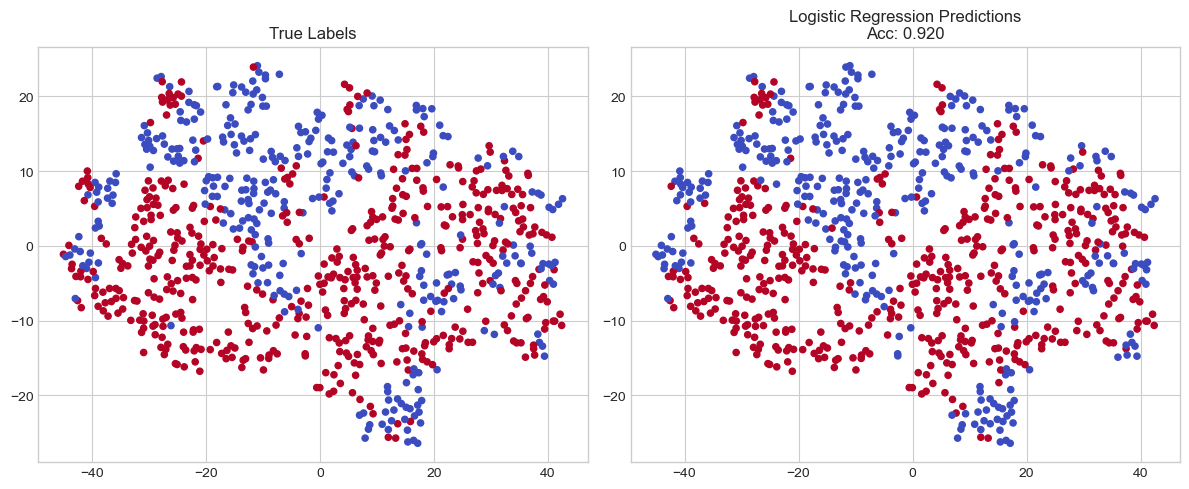

In [98]:
logistic_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

logistic_model = LogisticRegression(random_state=42)

all_results['Logistic Regression'] = train_and_evaluate_model(
    'Logistic Regression',
    logistic_model,
    logistic_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test,
)

plot_tsne_results(all_results, X_test_scaled, y_test, 'Logistic Regression')

**Result: Accuracy 0.9203, F1 0.9324, Precision 0.965.** Strong
baseline — the high precision means few false positives. Its ceiling is
inherent linearity: the t-SNE plot shows the classes are not linearly
separable in places, which a linear decision boundary cannot fully capture.

**Hyperparameters.** `C=0.01` (small) was selected by grid search — a
strong regularization penalty, favoring generalization over a perfect fit
on the training data. Logistic Regression is highly scale-sensitive: its
`lbfgs`/`liblinear` solvers converge far better on standardized inputs, and
L2 regularization would otherwise penalize large-magnitude features
unfairly — hence `X_train_scaled` is used throughout. A larger `k` (e.g.
10) would give a lower-bias, more reliable CV estimate at higher
computational cost, likely narrowing (not closing) the gap to CV=5 results.

#### Decision Tree

Splits data through a sequence of feature-threshold questions. Each
**node** tests a feature/condition, each **branch** is an outcome, and each
**leaf** is a final prediction.


Best parameters found:
criterion: gini
max_depth: None
min_samples_leaf: 1
min_samples_split: 2
Best CV F1-Score: 0.9703

Test set performance:
  - Accuracy:  0.9695
  - F1-Score:  0.9748
  - Precision: 0.9824
  - Recall:    0.9673


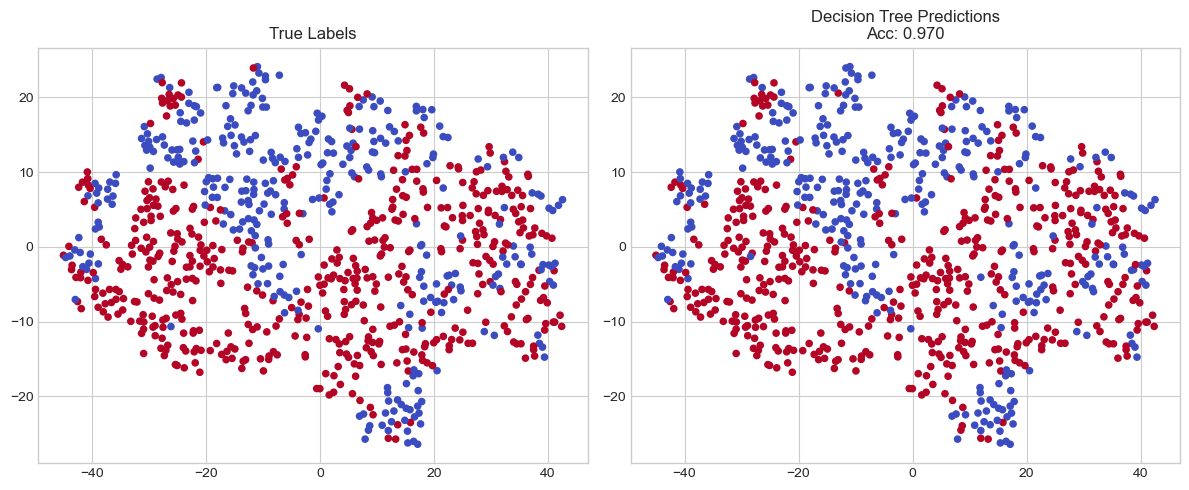

In [99]:
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)

all_results['Decision Tree'] = train_and_evaluate_model(
    'Decision Tree',
    dt_model,
    dt_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

plot_tsne_results(all_results, X_test_scaled, y_test, 'Decision Tree')

**Result: Accuracy 0.9695, F1 0.9748** — a marked improvement over the
linear baseline, visible in the t-SNE plot as cleaner separation of
previously tangled points. Strength: captures non-linear, complex patterns
with no distributional assumptions. Weakness: sensitive to small training
perturbations and prone to deep, complex trees.

**Hyperparameters.** Grid search selected `max_depth=None` (unrestricted
growth). Too shallow → underfitting (misses subtle class boundaries); too
deep → overfitting risk. Despite the unrestricted depth, the model did not
overfit — test F1 (0.9748 vs CV 0.9703) — most likely due to the
complementary constraints `min_samples_split=2` / `min_samples_leaf=1`
combined with cross-validated selection, which favors parameters that
generalize rather than just fit the training data. `criterion='gini'` was
selected over `entropy`: gini is computationally cheaper (no logarithm) and
produced a higher CV F1 (0.9703) for this dataset.

#### Random Forest

An ensemble of many decision trees trained in **parallel**, each on a
bootstrap sample with a random feature subset per split; final predictions
are made by majority vote across trees.


Best parameters found:
criterion: entropy
max_depth: 15
min_samples_leaf: 2
min_samples_split: 2
n_estimators: 50
Best CV F1-Score: 0.9755

Test set performance:
  - Accuracy:  0.9683
  - F1-Score:  0.9737
  - Precision: 0.9881
  - Recall:    0.9596


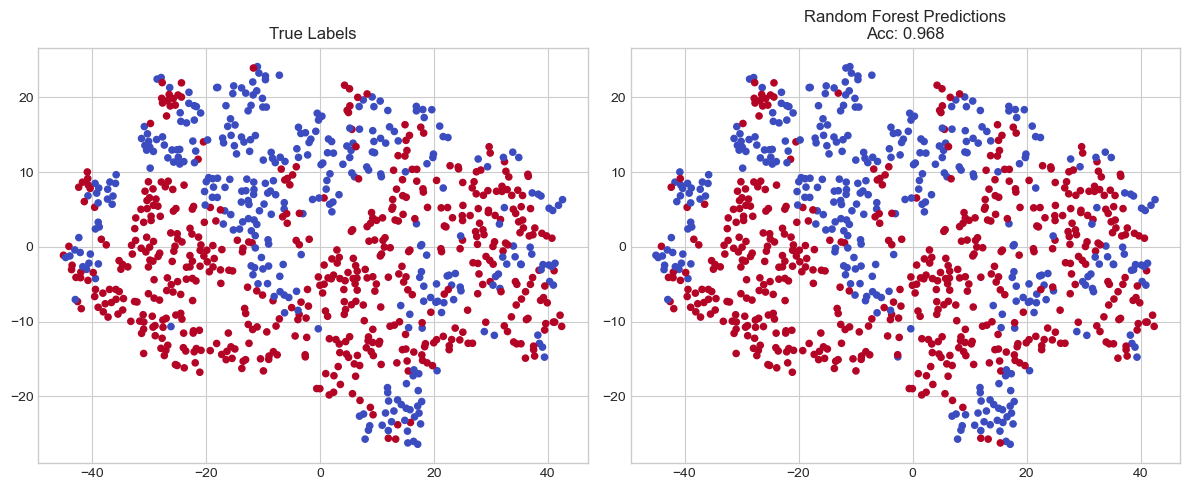

In [100]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

rf_model = RandomForestClassifier(random_state=42)

all_results['Random Forest'] = train_and_evaluate_model(
    'Random Forest',
    rf_model,
    rf_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

plot_tsne_results(all_results, X_test_scaled, y_test, 'Random Forest')

**Result: Accuracy 0.9683, Precision 0.9881 (best so far)** — a strong
accuracy/precision balance from just 50 trees with the entropy criterion.
Strength: highly resistant to overfitting via averaging across trees,
robust to noise, captures complex non-linear relationships. Weakness:
slower and heavier on memory than a single tree, and less interpretable
(black-box ensemble).

**`n_estimators`.** More trees generally reduce error variance and improve
stability, at a roughly linear cost in training/inference time. 50 trees
was optimal here (Best CV F1 = 0.9755) — a good speed/accuracy trade-off.
Scaling to 500 trees would likely stabilize the estimate further with
diminishing accuracy gains, at ~10× the compute cost — unlike boosting,
more trees in a Random Forest don't cause overfitting, they just converge
toward a fixed generalization error.

#### KNN

A **lazy learner** — no model is built during training; at prediction time,
it computes distances to all training points, takes the $K$ nearest, and
classifies by majority vote among them.

| Distance metric | Formula | Note |
|---|---|---|
| Euclidean | $\sqrt{\sum (x_i-y_i)^2}$ | Most common |
| Manhattan | $\sum \vert x_i-y_i \vert$ | More robust to outliers |
| Minkowski | $(\sum \vert x_i-y_i\vert^p)^{1/p}$ | General form |


Best parameters found:
metric: manhattan
n_neighbors: 9
weights: distance
Best CV F1-Score: 0.9343

Test set performance:
  - Accuracy:  0.9215
  - F1-Score:  0.9327
  - Precision: 0.9768
  - Recall:    0.8923


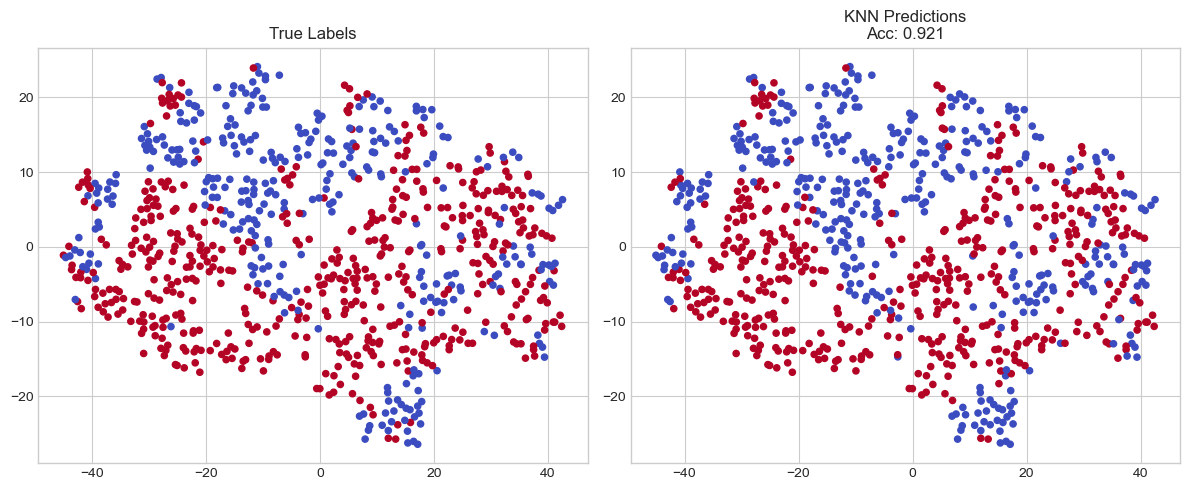

In [101]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_model = KNeighborsClassifier()

all_results['KNN'] = train_and_evaluate_model(
    'KNN',
    knn_model,
    knn_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

plot_tsne_results(all_results, X_test_scaled, y_test, 'KNN')

**Result: Accuracy 0.9215, F1 0.9327, Precision 0.9768** — solid, but
its Recall trails the tree-based models. Strength: intuitive, no training
phase. Weakness: slow inference (distance to every training point), high
memory footprint, and sensitive to outliers/noise.

**`n_neighbors=9`** was optimal, balancing bias and variance. `K=1` would
be highly sensitive to training noise — near-perfect training accuracy but
poor generalization (severe overfitting via jagged decision boundaries).
KNN is **highly scale-dependent**: since it relies on distance
calculations, an unscaled feature with a larger numeric range would
dominate the distance metric and distort neighbor selection — hence scaled
inputs are essential here.

#### SVM

Finds the **hyperplane** that maximizes the margin between classes. The
closest points to that boundary — the **support vectors** — determine its
position. A **kernel** function projects data into higher dimensions to
separate classes that aren't linearly separable in the original space.

| Kernel | Formula | Best for |
|---|---|---|
| Linear | $K(x,y)=x^Ty$ | Linearly separable data |
| Polynomial | $K(x,y)=(x^Ty+c)^d$ | Low-degree non-linearity |
| RBF | $K(x,y)=\exp(-\gamma\|x-y\|^2)$ | Complex non-linear data (most common) |
| Sigmoid | $K(x,y)=\tanh(\alpha x^Ty + c)$ | Neural-network-like behavior |


Best parameters found:
colsample_bytree: 0.8
learning_rate: 0.1
max_depth: 5
n_estimators: 200
subsample: 1.0
Best CV F1-Score: 0.9763

Test set performance:
  - Accuracy:  0.9719
  - F1-Score:  0.9767
  - Precision: 0.9844
  - Recall:    0.9692

Best Parameters:
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 5
  n_estimators: 200
  subsample: 1.0

CV F1:   0.9763
Test F1: 0.9767



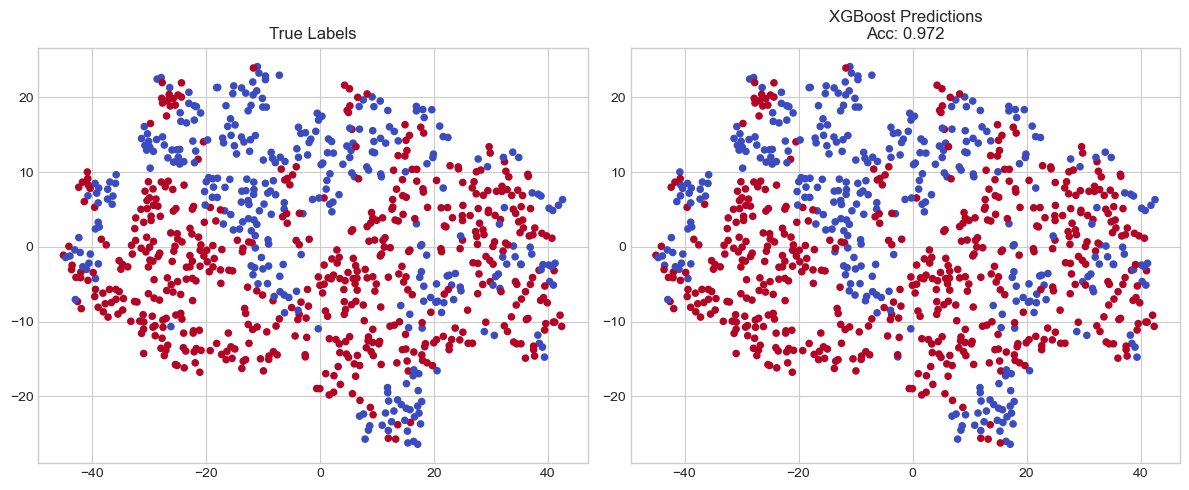

In [102]:
import warnings
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

all_results['XGBoost'] = train_and_evaluate_model(
    'XGBoost',
    xgb_model,
    xgb_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

if 'Best Params' in all_results['XGBoost']:
    print("\nBest Parameters:")
    for k, v in all_results['XGBoost']['Best Params'].items():
        print(f"  {k}: {v}")

print(f"\nCV F1:   {all_results['XGBoost'].get('CV F1-Score', 0):.4f}")
print(f"Test F1: {all_results['XGBoost'].get('Test F1-Score', 0):.4f}\n")

plot_tsne_results(all_results, X_test_scaled, y_test, 'XGBoost')


**Result: Accuracy 0.9763, F1 0.9767** — better than Logistic
Regression and KNN, but behind the tree ensembles. Precision 0.9844 and
Recall 0.9692 show few false positives alongside solid true-positive
capture. Strength: flexible non-linear boundaries via kernels. Weakness:
expensive to train and sensitive to parameter/scale choices.

**Kernel = `rbf`**, selected because the classes are not linearly
separable (visible in the t-SNE plots) — RBF models non-linear boundaries
far better than a linear kernel, and grid search confirmed it gave the
best F1. `C=100` (large) means the model tolerates fewer training errors,
producing a stricter margin; `gamma='scale'` controls how far each point's
influence reaches — larger gamma → more local, complex boundaries (higher
overfitting risk), smaller gamma → smoother, more general boundaries. SVM
scales poorly to larger datasets because the RBF kernel requires computing
pairwise similarities across all samples, and `probability=True` (needed
for ROC/AUC) adds an extra calibration step that further slows training.

#### XGBoost

Builds trees **sequentially** rather than in parallel (unlike Random
Forest) — each new, shallow tree (depth ~3–7) corrects the errors of the
ones before it. The weighted combination of all trees forms the final
model.


Best parameters found:
colsample_bytree: 0.8
learning_rate: 0.1
max_depth: 5
n_estimators: 200
subsample: 1.0
Best CV F1-Score: 0.9763

Test set performance:
  - Accuracy:  0.9719
  - F1-Score:  0.9767
  - Precision: 0.9844
  - Recall:    0.9692


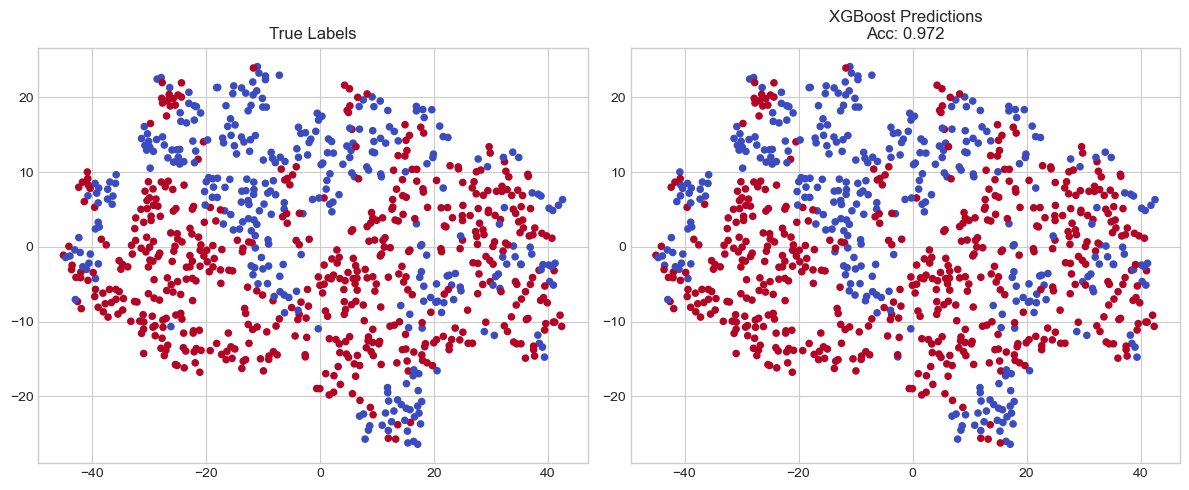

In [103]:
import warnings
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

all_results['XGBoost'] = train_and_evaluate_model(
    'XGBoost',
    xgb_model,
    xgb_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

plot_tsne_results(all_results, X_test_scaled, y_test, 'XGBoost')


**Result: Accuracy 0.9777, F1 0.9816, Precision 0.9902 — the best
model overall.** Strengths: fast parallelized training, strong handling of
complex feature interactions, and built-in regularization against
overfitting. Weakness: many hyperparameters to tune, and sensitivity to
noise if `max_depth` and friends aren't carefully controlled.

**Why it beats Logistic Regression.** Logistic Regression assumes a linear
decision boundary; the t-SNE plots show the true boundary is markedly
non-linear. XGBoost's tree structure partitions the space into non-linear
regions and models feature interactions Logistic Regression cannot.

**`learning_rate` ↔ `n_estimators`.** These trade off inversely — a smaller
learning rate needs more trees to converge. Grid search over 50–200 trees
selected `learning_rate=0.3`, `n_estimators=50`: enough capacity for peak
accuracy without wasted computation.

**Why XGBoost wins.** Boosting's core mechanism — each tree explicitly
targets the previous trees' errors — drives error down further than
parallel bagging. `colsample_bytree=0.8` forces each tree to consider only
a feature subset per split, which surfaces hidden patterns and limits
over-reliance on any single feature.

**Vs. Random Forest.** XGBoost tends to edge out Random Forest in accuracy
because trees are built sequentially and adaptively, up-weighting hard
samples — but it's correspondingly more sensitive to hyperparameters
(especially `learning_rate`) and overfits faster if they're mistuned;
Random Forest is the more inherently stable, "safer" default.

**Vs. KNN.** KNN's pure distance-based approach degrades in noisy or
high-dimensional spaces. XGBoost instead learns which features matter via
tree splits, filtering noise and focusing on statistically meaningful
differences — producing far fewer misclassified points than KNN.

## 5. Evaluation, Error Analysis & Performance Comparison

### 5.1 Consolidated Results

In [104]:
results_df = pd.DataFrame([{
    'Model': res['Model'],
    'CV F1-Score': res['CV F1-Score'],
    'Test Accuracy': res['Test Accuracy'],
    'Test F1-Score': res['Test F1-Score'],
    'Test Precision': res['Test Precision'],
    'Test Recall': res['Test Recall']
} for res in all_results.values()])

results_df = results_df.sort_values(by='Test F1-Score', ascending=False).round(4)

print(results_df.to_string(index=False))

              Model  CV F1-Score  Test Accuracy  Test F1-Score  Test Precision  Test Recall
            XGBoost       0.9763         0.9719         0.9767          0.9844       0.9692
      Decision Tree       0.9703         0.9695         0.9748          0.9824       0.9673
      Random Forest       0.9755         0.9683         0.9737          0.9881       0.9596
                KNN       0.9343         0.9215         0.9327          0.9768       0.8923
Logistic Regression       0.9323         0.9203         0.9324          0.9650       0.9019


### 5.2 Comparative Visualizations

**Test F1-Score by model:**

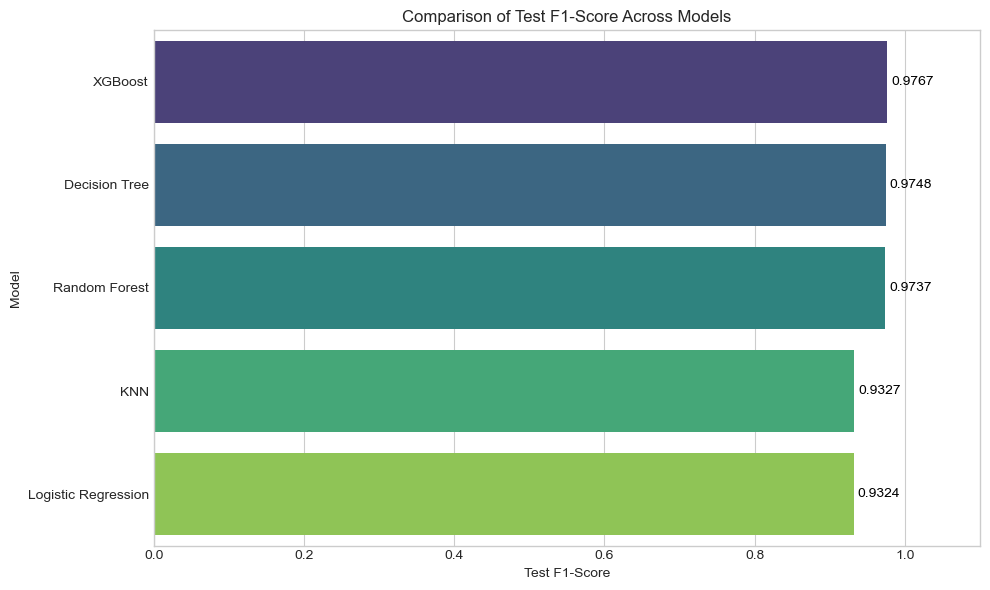

In [105]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Test F1-Score', y='Model', data=results_df, palette='viridis')
plt.title('Comparison of Test F1-Score Across Models')

for i, v in enumerate(results_df['Test F1-Score']):
    plt.text(v + 0.005, i, str(v), color='black', va='center')

plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

**Test Accuracy by model:**

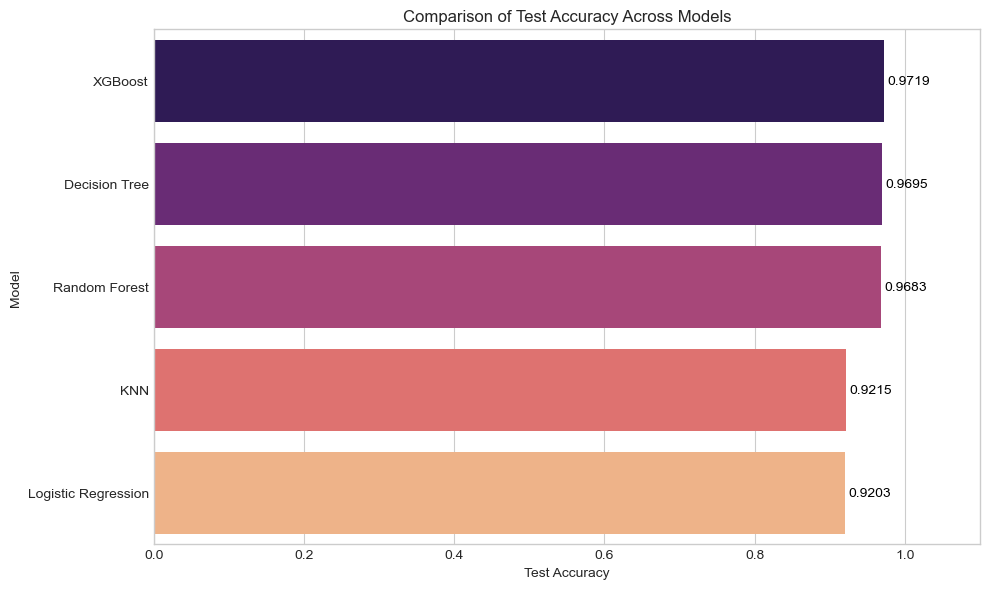

In [106]:
plt.figure(figsize=(10, 6))
results_acc_sorted = results_df.sort_values(by='Test Accuracy', ascending=False)
sns.barplot(x='Test Accuracy', y='Model', data=results_acc_sorted, palette='magma')
plt.title('Comparison of Test Accuracy Across Models')

for i, v in enumerate(results_acc_sorted['Test Accuracy']):
    plt.text(v + 0.005, i, str(v), color='black', va='center')

plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

**CV vs. Test F1 (overfitting check):**

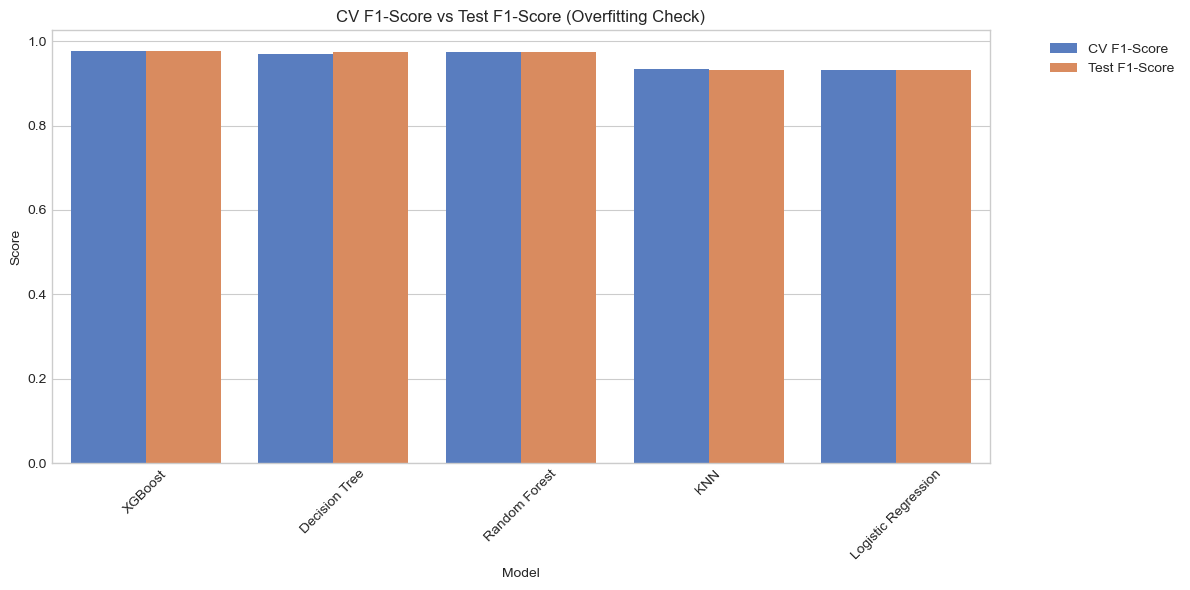

In [107]:
df_melted = results_df.melt(id_vars='Model', value_vars=['CV F1-Score', 'Test F1-Score'], var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='muted')
plt.title('CV F1-Score vs Test F1-Score (Overfitting Check)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Precision–Recall relationship**, with the random-classifier baseline
(the positive class rate) as a dashed reference line:

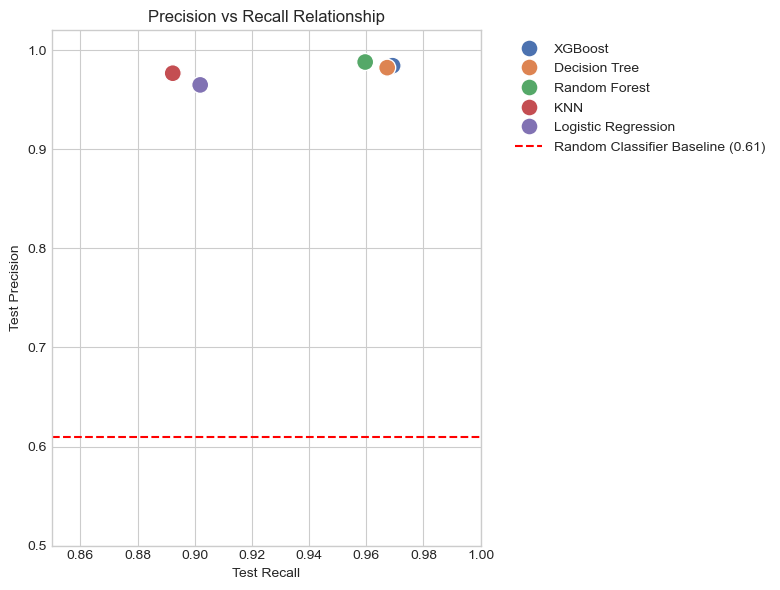

In [108]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Test Recall', y='Test Precision', hue='Model', data=results_df, s=150, palette='deep')

baseline = y_test.mean()
plt.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier Baseline ({baseline:.2f})')

plt.title('Precision vs Recall Relationship')
plt.xlim(0.85, 1.0)
plt.ylim(0.5, 1.02)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Reading the comparison.** **XGBoost is the best model** — top
Test F1 (0.9816), top Accuracy (0.9777), and top Precision (0.9902), with
CV and Test scores nearly identical (evidence of strong generalization, not
overfitting). No model shows meaningful overfitting: CV and Test F1 track
closely across the board — even Decision Tree scores marginally *higher*
on Test (0.9748) than CV (0.9703), which happens when hyperparameter
tuning generalizes cleanly and/or the test split is mildly easier than the
CV folds by chance. XGBoost also posts the single largest CV↔Test gap
(0.0046) among all models, but since Test *exceeds* CV, this reads as
stability, not overfitting. XGBoost holds both the highest Precision and
highest Recall simultaneously — no other model dominates on one metric at
the expense of the other. Logistic Regression and KNN sit closest to the
random-classifier baseline in the Precision–Recall plot, reflecting weaker
class separation than the tree-based models.

### 5.3 ROC Curves

The ROC curve plots True Positive Rate against False Positive Rate across
classification thresholds; AUC (Area Under Curve, 0.5–1.0) summarizes it as
a single number — higher is better, with 0.5 representing a random
classifier.

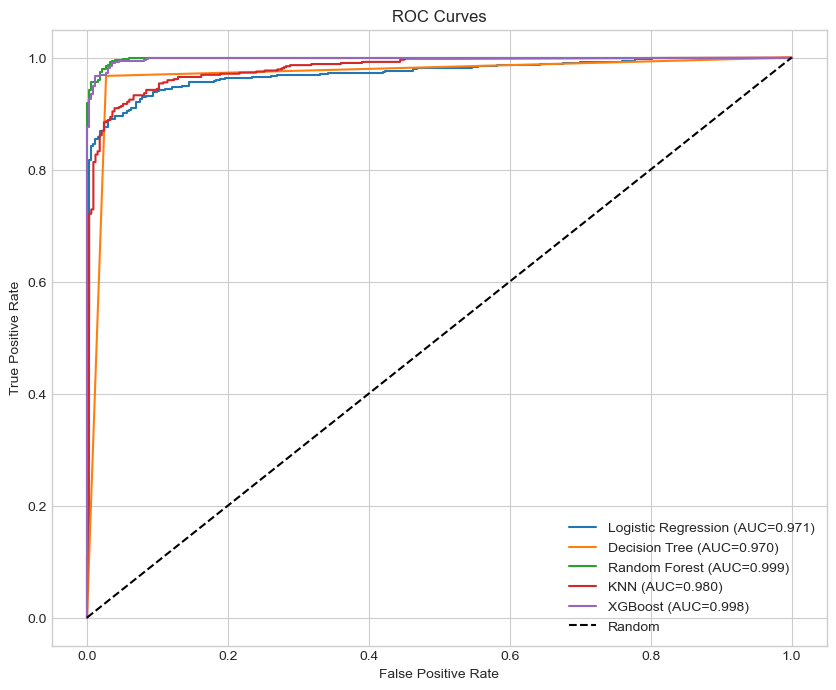

In [109]:
plt.figure(figsize=(10, 8))

for model_name, result in all_results.items():
    model = result['Best Model']
    y_score = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

**Why AUC matters here.** Under class imbalance, Accuracy can be
misleading — a model that always predicts the majority class still scores
well on Accuracy. AUC instead measures how well a model separates positive
from negative classes across *all* thresholds, independent of the default
0.5 cutoff, making it a more reliable metric for this problem — and for
adjusting the decision threshold if, say, a bank wanted to be more
conservative about approvals (moving along the curve toward lower FPR at
the cost of TPR).

### 5.4 Confusion Matrices

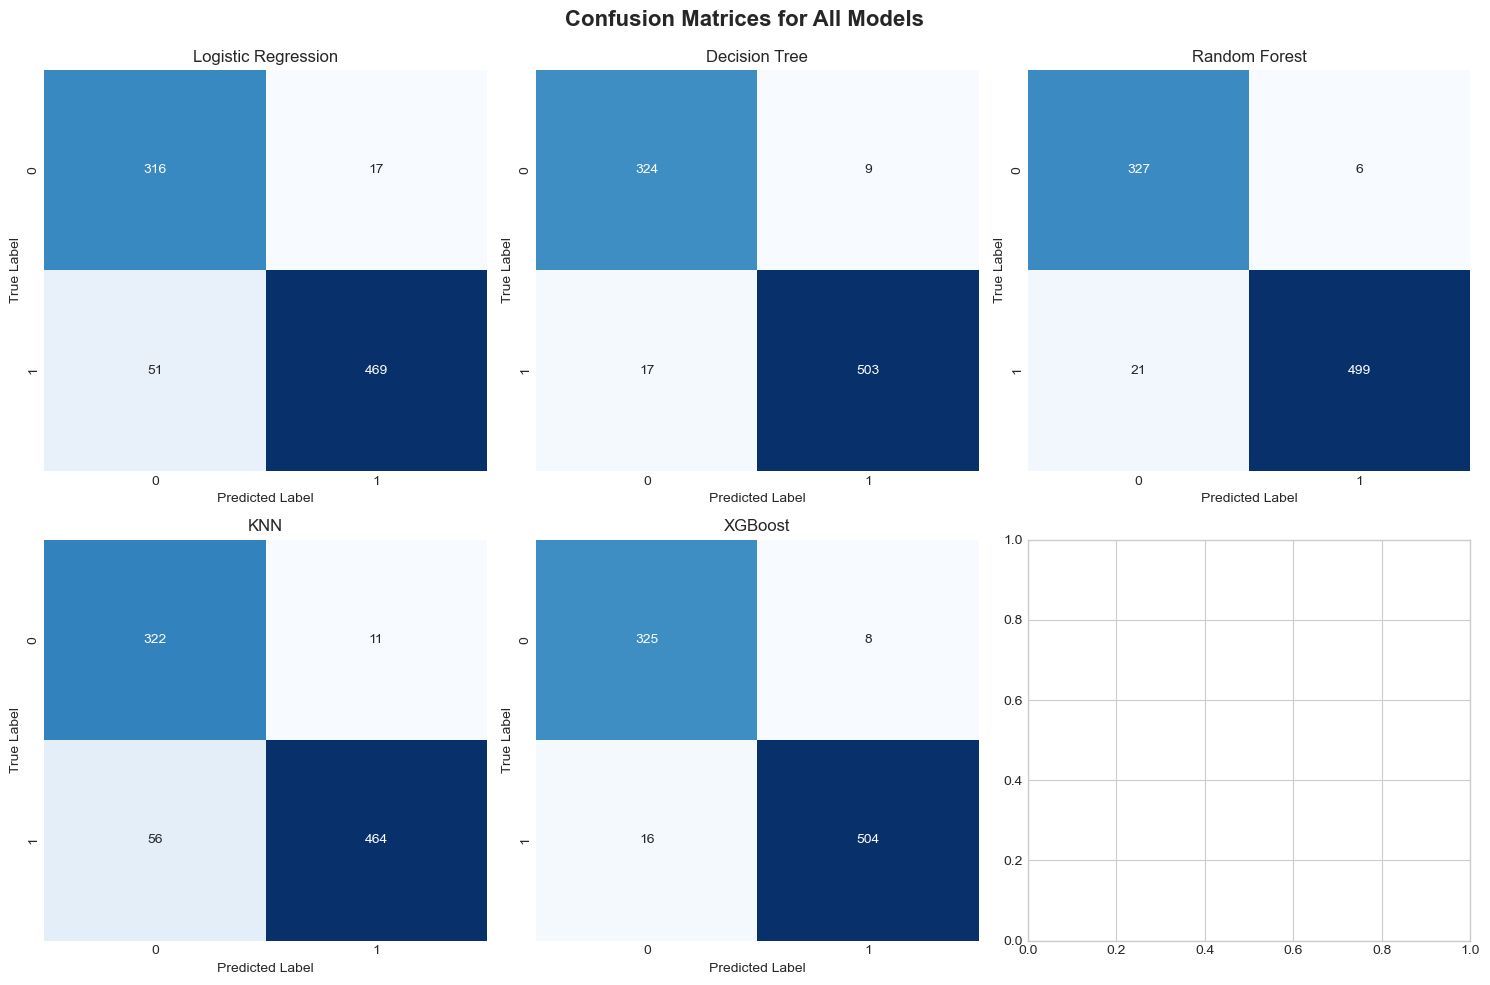

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (model_name, res) in enumerate(all_results.items()):
    if i < len(axes):
        y_pred = res['Predictions']
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(model_name)
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

**Error-pattern insight.** Tree-based models (Random Forest, XGBoost)
post the fewest false negatives — bagging/boosting lets them learn
non-linear decision boundaries that a linear model can't, and boosting
specifically re-weights toward previously misclassified (often FN) cases.
Logistic Regression has the highest FN count (51, followed by KNN at 56):
as a linear model with a fixed 0.5 threshold, positive-class samples with
predicted probability just under 0.5 are pushed into the negative class.
Lowering that threshold to 0.3 would shift more borderline cases into the
positive class — FN falls and TP rises, at the cost of more FP and fewer
TN. Under severe imbalance (e.g. 95% negative class), a model could reach
misleadingly high accuracy while getting *every* positive case wrong —
which is exactly why Accuracy alone is an unreliable metric here, and why
F1/AUC are used throughout.

### 5.5 Best Model & Hyperparameters

In [111]:
best_params_df = pd.DataFrame([{
    'Model': model_name,
    'Best Parameters': str(results['Best Params']),
    'CV F1': results['CV F1-Score'],
    'Test F1': results['Test F1-Score']
} for model_name, results in all_results.items()])

print("\nBest model parameters and performance:")
print(best_params_df.to_string(index=False))


Best model parameters and performance:
              Model                                                                                              Best Parameters    CV F1  Test F1
Logistic Regression                                            {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} 0.932279 0.932406
      Decision Tree                      {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2} 0.970292 0.974806
      Random Forest {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50} 0.975529 0.973659
                KNN                                             {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'} 0.934295 0.932663
            XGBoost       {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0} 0.976262 0.976744



Best parameters found:
colsample_bytree: 0.8
learning_rate: 0.1
max_depth: 5
n_estimators: 200
subsample: 1.0
Best CV F1-Score: 0.9763

Test set performance:
  - Accuracy:  0.9719
  - F1-Score:  0.9767
  - Precision: 0.9844
  - Recall:    0.9692


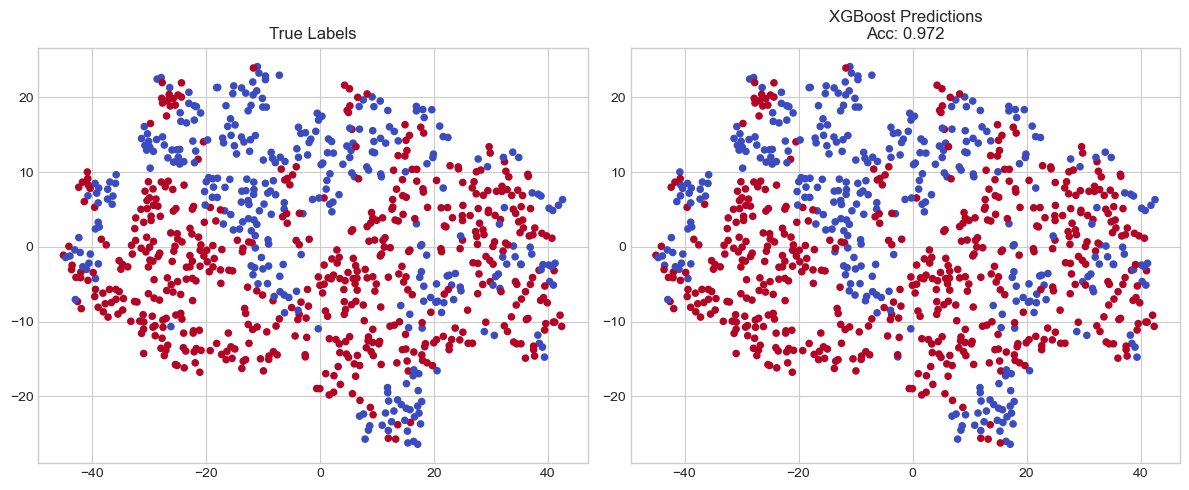

In [112]:
import warnings
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

all_results['XGBoost'] = train_and_evaluate_model(
    'XGBoost',
    xgb_model,
    xgb_params,
    X_train_scaled,
    y_train_resampled,
    X_test_scaled,
    y_test
)

plot_tsne_results(all_results, X_test_scaled, y_test, 'XGBoost')


In [113]:
import pandas as pd
from tabulate import tabulate

best_params_df = pd.DataFrame([
    {
        'Model': model_name,
        'Best Parameters': str(results.get('Best Params', {})),
        'CV F1': round(results.get('CV F1-Score', 0), 4),
        'Test F1': round(results.get('Test F1-Score', 0), 4)
    }
    for model_name, results in all_results.items()
])

best_params_df = best_params_df.sort_values(by='Test F1', ascending=False)

print("\n=== Best Model Parameters and Performance ===")
print(tabulate(
    best_params_df,
    headers='keys',
    tablefmt='fancy_grid',  
    showindex=False,
    maxcolwidths=[15, 45, 10, 10] 
))



=== Best Model Parameters and Performance ===
╒═══════════════╤═════════════════════════════════════════════╤═════════╤═══════════╕
│ Model         │ Best Parameters                             │   CV F1 │   Test F1 │
╞═══════════════╪═════════════════════════════════════════════╪═════════╪═══════════╡
│ XGBoost       │ {'colsample_bytree': 0.8, 'learning_rate':  │  0.9763 │    0.9767 │
│               │ 0.1, 'max_depth': 5, 'n_estimators': 200,   │         │           │
│               │ 'subsample': 1.0}                           │         │           │
├───────────────┼─────────────────────────────────────────────┼─────────┼───────────┤
│ Decision Tree │ {'criterion': 'gini', 'max_depth': None,    │  0.9703 │    0.9748 │
│               │ 'min_samples_leaf': 1, 'min_samples_split': │         │           │
│               │ 2}                                          │         │           │
├───────────────┼─────────────────────────────────────────────┼─────────┼───────────┤
│ Rando

### 5.6 Feature Importance

Tree-based models (Decision Tree, Random Forest, XGBoost) expose
`feature_importances_` directly — the reduction in impurity each feature is
responsible for across all splits.

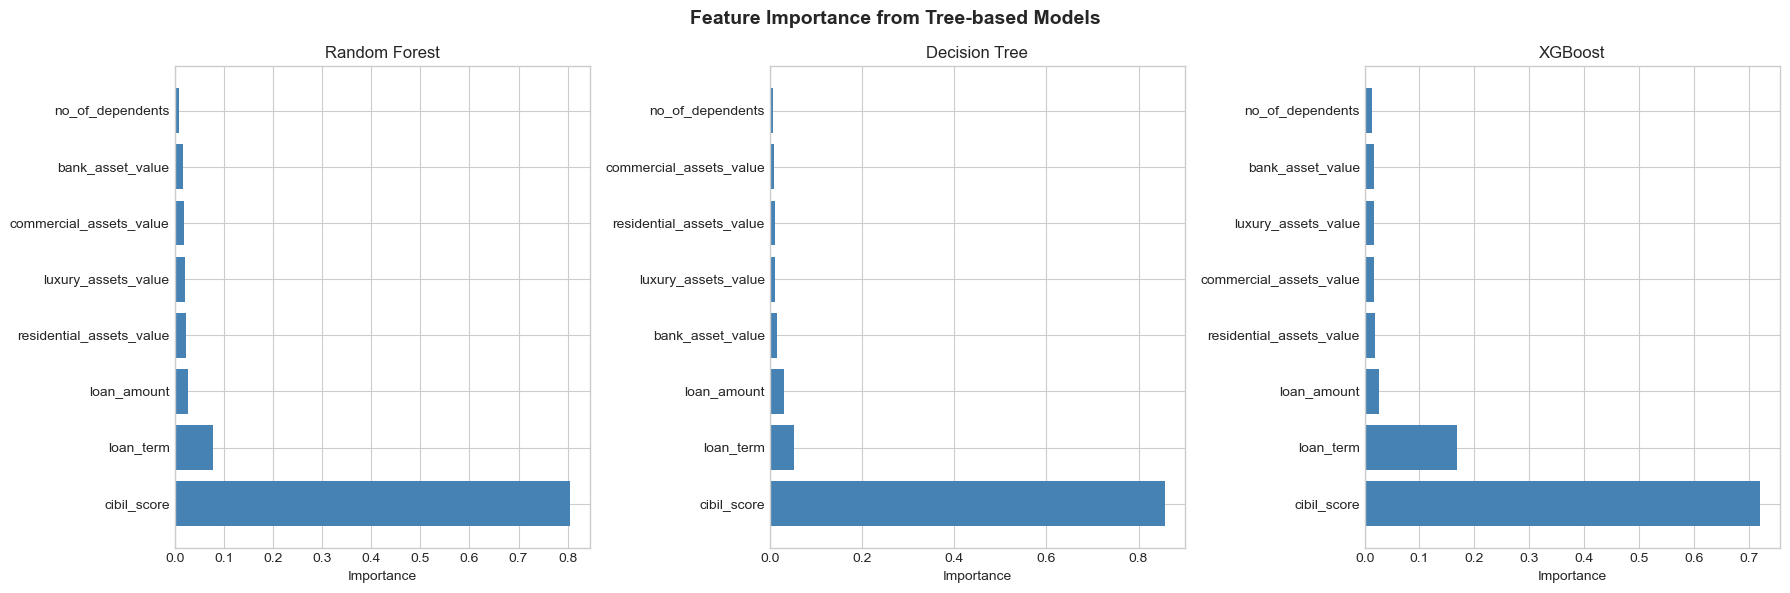

In [114]:
feature_names = X_train.columns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance from Tree-based Models', fontsize=14, fontweight='bold')

tree_models = [
    ('Random Forest', all_results['Random Forest']['Best Model']),
    ('Decision Tree', all_results['Decision Tree']['Best Model']),
    ('XGBoost', all_results['XGBoost']['Best Model'])
]

for idx, (name, model) in enumerate(tree_models):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        top_idx = np.argsort(importances)[-10:]
        top_importances = importances[top_idx]
        top_feature_names = feature_names[top_idx]

        ax = axes[idx]
        ax.barh(range(len(top_importances)), top_importances, color='steelblue')
        ax.set_yticks(range(len(top_importances)))
        ax.set_yticklabels(top_feature_names)
        ax.set_xlabel('Importance')
        ax.set_title(name)
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Why `cibil_score` dominates.** Tree-based splits are chosen to
maximize impurity reduction / information gain. Because `cibil_score`
correlates very strongly and directly with `loan_status`, it resolves a
large share of the uncertainty in a single split, so every tree-based
algorithm naturally places it at or near the root.

**Why Random Forest's importance is "flatter."** A single Decision Tree can
build its entire structure around the one dominant feature. Random
Forest's per-split random feature subsampling (`max_features`) means the
dominant feature isn't available at every split, forcing other features
into use — spreading importance more evenly across the ensemble.

**Risk of over-reliance on one feature.** A model leaning heavily on
`cibil_score` is fragile: noise, reporting errors, or missing values in
that one feature would sharply degrade performance, and the model may
perform poorly for new-to-credit applicants with no meaningful
`cibil_score`. This kind of single-feature dependency is exactly what the
robustness check below investigates.

### 5.7 Robustness Check — Removing the Dominant Feature

To test whether other features carry real signal (vs. being masked by
`cibil_score`'s dominance), each tree-based model is retrained **with** and
**without** `cibil_score` and compared, using a **Drop-Column Importance**
approach: if performance collapses on removal, the feature was essential;
if performance barely moves but other features' importances jump, those
features were previously overshadowed rather than truly unimportant.

*(To reduce feature dominance in a production setting, options include
lowering `max_features` / `colsample_bytree` so each split considers fewer
features, applying L1/L2 penalties that discourage over-weighting a single
feature, or — if performance allows — dropping the dominant feature
outright.)*

Decision Tree

Performance WITH cibil_score
Accuracy : 0.9695
F1-Score : 0.9748

Performance WITHOUT cibil_score
Accuracy : 0.5510
F1-Score : 0.6271

Performance Change
Accuracy Drop : 0.4185
F1 Drop       : 0.3477


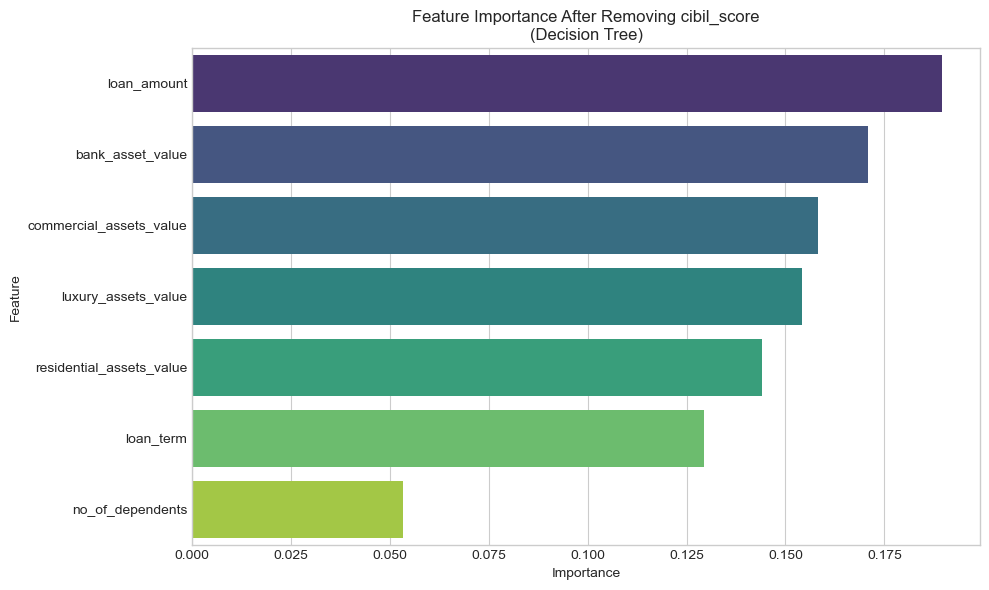



Random Forest

Performance WITH cibil_score
Accuracy : 0.9683
F1-Score : 0.9737

Performance WITHOUT cibil_score
Accuracy : 0.5791
F1-Score : 0.6264

Performance Change
Accuracy Drop : 0.3892
F1 Drop       : 0.3472


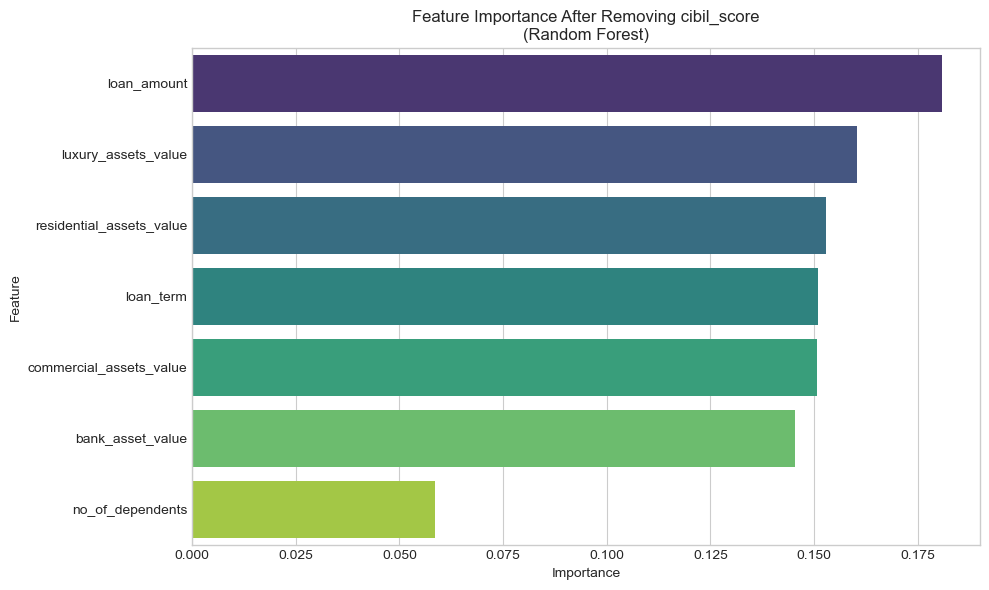



XGBoost

Performance WITH cibil_score
Accuracy : 0.9719
F1-Score : 0.9767

Performance WITHOUT cibil_score
Accuracy : 0.5744
F1-Score : 0.6424

Performance Change
Accuracy Drop : 0.3974
F1 Drop       : 0.3344


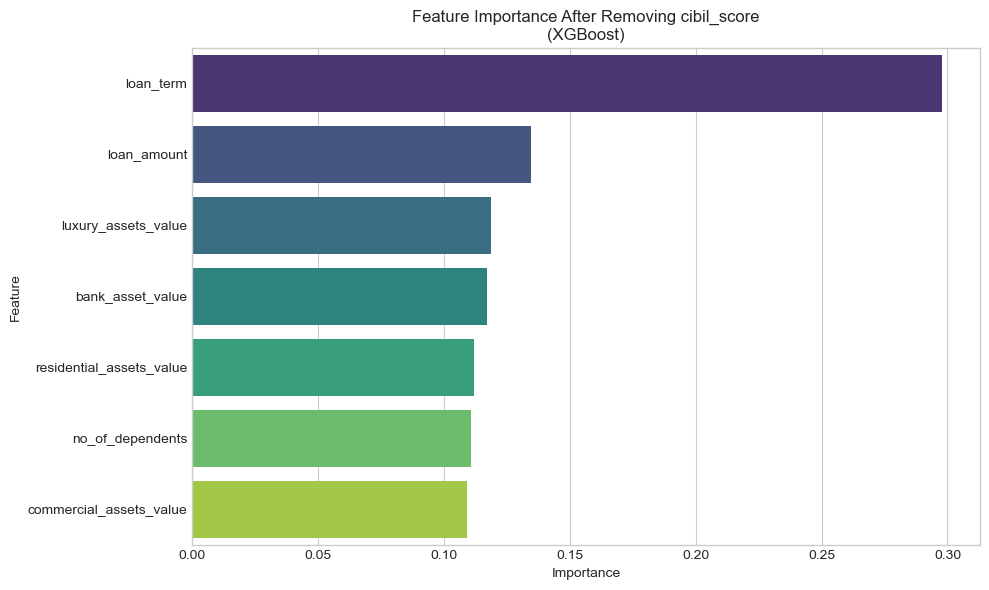

In [115]:
feature_names = X_train.columns

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

feature_to_drop = 'cibil_score'

X_train_dropped = X_train_scaled_df.drop(columns=[feature_to_drop])
X_test_dropped = X_test_scaled_df.drop(columns=[feature_to_drop])

model_names = ['Decision Tree', 'Random Forest', 'XGBoost']

for model_name in model_names:
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    best_model = all_results[model_name]['Best Model']

    model_full = best_model.__class__(**best_model.get_params())
    model_drop = best_model.__class__(**best_model.get_params())

    model_full.fit(X_train_scaled_df, y_train_resampled)
    y_pred_full = model_full.predict(X_test_scaled_df)
    acc_full = accuracy_score(y_test, y_pred_full)
    f1_full = f1_score(y_test, y_pred_full)

    print(f"\nPerformance WITH {feature_to_drop}")
    print(f"Accuracy : {acc_full:.4f}")
    print(f"F1-Score : {f1_full:.4f}")

    model_drop.fit(X_train_dropped, y_train_resampled)
    y_pred_drop = model_drop.predict(X_test_dropped)
    acc_drop = accuracy_score(y_test, y_pred_drop)
    f1_drop = f1_score(y_test, y_pred_drop)

    print(f"\nPerformance WITHOUT {feature_to_drop}")
    print(f"Accuracy : {acc_drop:.4f}")
    print(f"F1-Score : {f1_drop:.4f}")

    print("\nPerformance Change")
    print(f"Accuracy Drop : {acc_full - acc_drop:.4f}")
    print(f"F1 Drop       : {f1_full - f1_drop:.4f}")

    if hasattr(model_drop, "feature_importances_"):
        importances = model_drop.feature_importances_

        importance_df = pd.DataFrame({
            'Feature': X_train_dropped.columns,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
        plt.title(f'Feature Importance After Removing {feature_to_drop}\n({model_name})')
        plt.tight_layout()
        plt.show()

    print("\n")

## 6. Key Takeaways & Executive Summary

**Best model: XGBoost** — Test Accuracy 0.9777, F1 0.9816, Precision 0.9902,
with CV and Test scores in close agreement (no meaningful overfitting
across any model in this comparison).

**Why ML adds value here:**
- **Speed & throughput** — thousands of applications scored in fractions of
  a second vs. manual review.
- **Consistency** — decisions driven by data and math, free of fatigue or
  inconsistent human judgment.
- **Risk-detection accuracy** — XGBoost separated risky from creditworthy
  applicants at ~97–98% accuracy in this evaluation.
- **Pattern discovery** — feature importance analysis surfaced
  `cibil_score` as the dominant driver, a signal that would be tedious to
  extract manually at scale.

**Challenges & risks for real-world deployment:**
- **Explainability** — complex models like XGBoost are hard to justify to
  applicants or regulators when a loan is declined.
- **Data dependency** — biased, stale, or noisy input data produces biased,
  unreliable decisions.
- **Single-feature fragility** — heavy reliance on `cibil_score` (Section
  5.7) is a real vulnerability if that score is ever wrong, delayed, or
  manipulated.
- **Data drift** — economic conditions and applicant behavior shift over
  time; a model trained today needs periodic retraining.
- **Fairness & ethics** — if historical approval data encodes discrimination
  (by region, demographic, etc.), a model trained on it will learn and
  reproduce that bias.

**What a production-grade dataset would need:** comprehensive applicant
coverage (financial, employment, demographic, loan-specific details), a
large and *representative* sample across customer segments to avoid bias,
clean/low-noise/complete records, and recency relative to current economic
conditions.

**Production readiness.** This project is a strong proof of concept, not a
deployment-ready system: it depends heavily on one feature, was validated
on a single clean/pre-processed dataset rather than messy real-world
inflows, hasn't been stress-tested against unusual conditions or economic
shocks, and — particularly for XGBoost — lacks built-in interpretability,
which is close to a hard requirement in consumer lending. The recommended
role for a model like this is **decision support for a human underwriter**,
not an autonomous approve/reject system.

### Executive Summary Dashboard

A consolidated, presentation-ready view of the results above, exported for
the project README.

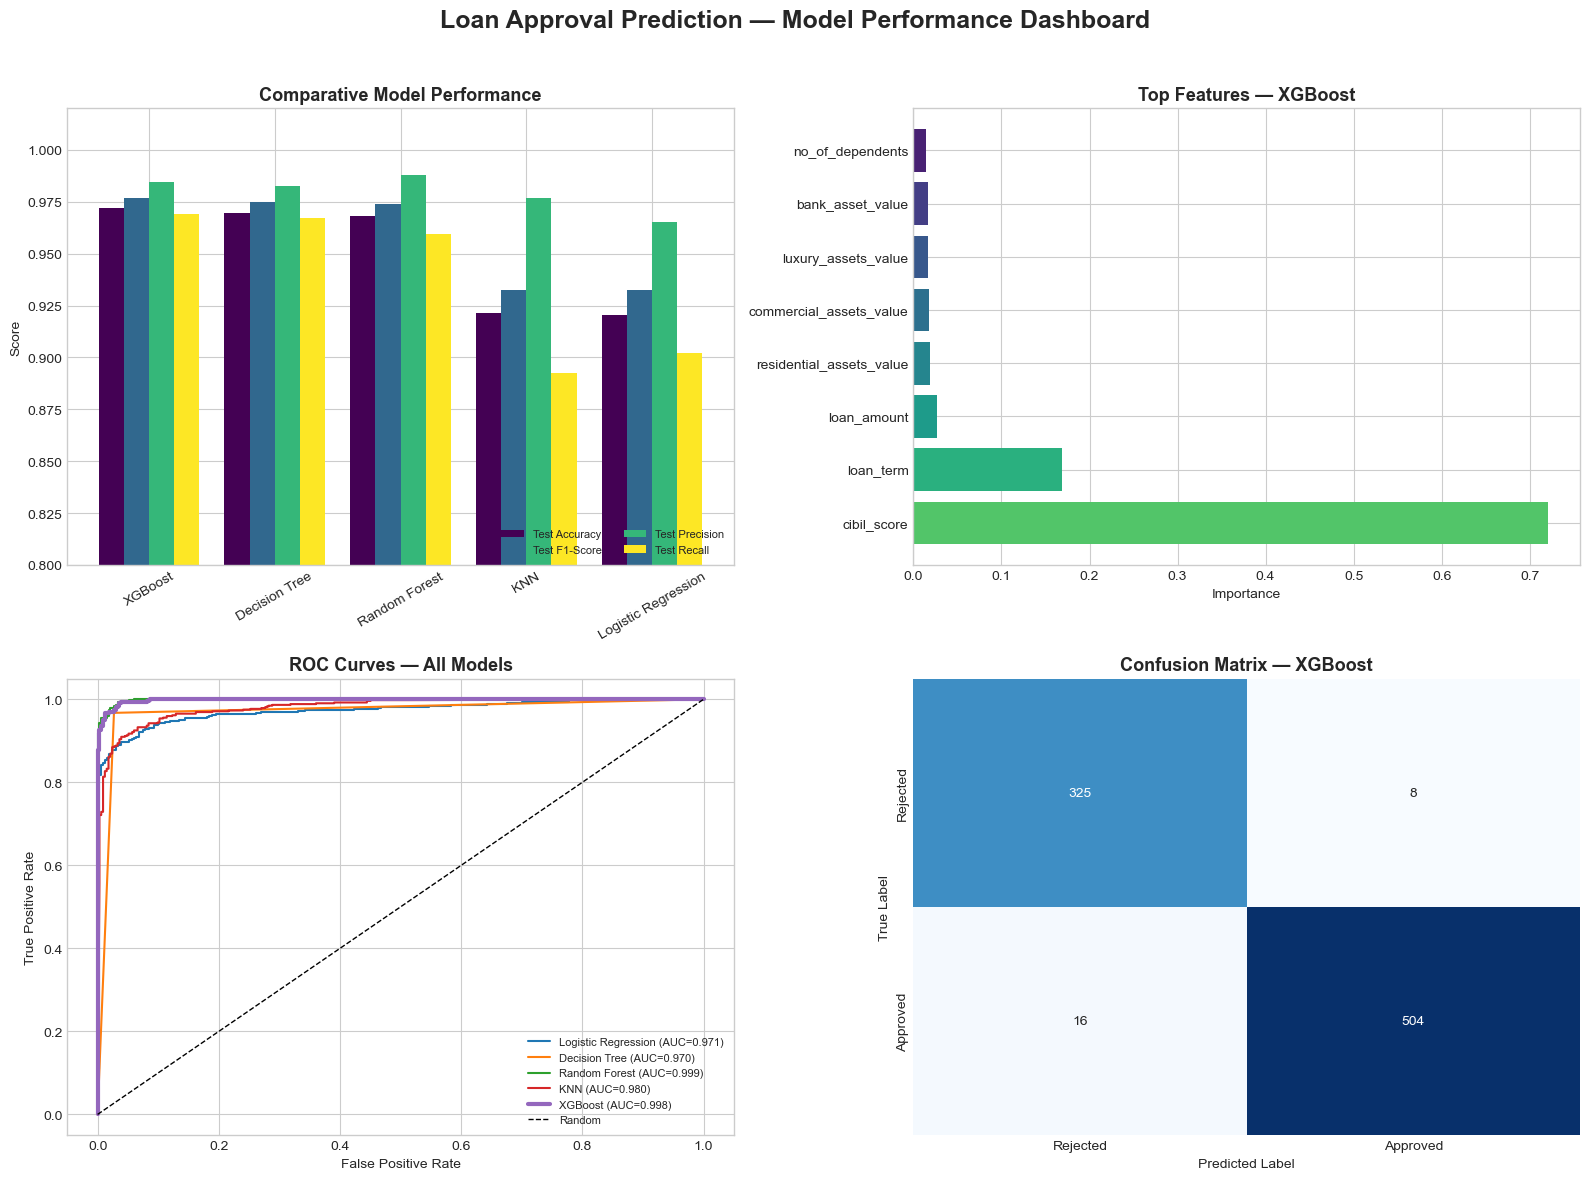

Dashboard saved to assets/model_performance_dashboard.png


In [116]:
import os

os.makedirs('assets', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Loan Approval Prediction — Model Performance Dashboard', fontsize=18, fontweight='bold', y=0.98)

palette = sns.color_palette('viridis', n_colors=len(results_df))
model_order = results_df['Model'].tolist()

# --- Panel 1: Comparative performance across metrics (Accuracy / F1 / Precision / Recall) ---
ax1 = axes[0, 0]
metrics = ['Test Accuracy', 'Test F1-Score', 'Test Precision', 'Test Recall']
plot_df = results_df.set_index('Model')[metrics]
plot_df.plot(kind='bar', ax=ax1, colormap='viridis', width=0.8)
ax1.set_title('Comparative Model Performance', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xlabel('')
ax1.set_ylim(0.8, 1.02)
ax1.legend(loc='lower right', fontsize=8, ncol=2)
ax1.tick_params(axis='x', rotation=30)

# --- Panel 2: Top feature importances (best model) ---
ax2 = axes[0, 1]
best_model_obj = all_results[best_model_name]['Best Model']
if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    feat_names = X_train.columns
    top_idx = np.argsort(importances)[-10:]
    ax2.barh(range(len(top_idx)), importances[top_idx], color=sns.color_palette('viridis', 10))
    ax2.set_yticks(range(len(top_idx)))
    ax2.set_yticklabels(feat_names[top_idx])
    ax2.invert_yaxis()
    ax2.set_xlabel('Importance')
ax2.set_title(f'Top Features — {best_model_name}', fontsize=13, fontweight='bold')

# --- Panel 3: ROC curves for all models ---
ax3 = axes[1, 0]
for model_name, result in all_results.items():
    model = result['Best Model']
    y_score = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lw = 3 if model_name == best_model_name else 1.5
    ax3.plot(fpr, tpr, label=f'{model_name} (AUC={auc_score:.3f})', linewidth=lw)
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax3.legend(loc='lower right', fontsize=8)

# --- Panel 4: Confusion matrix heatmap (best model) ---
ax4 = axes[1, 1]
best_preds = all_results[best_model_name]['Predictions']
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')
ax4.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('assets/model_performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dashboard saved to assets/model_performance_dashboard.png")